In [1]:
using Pkg
Pkg.activate("C:/Users/selha/Desktop/MAAAI/environment")  # <-- CAMBIAR A TU RUTA DE ENV


  Activating project at `C:\Users\selha\Desktop\MAAAI\environment`


In [2]:
Pkg.instantiate()   # solo necesario la primera vez 

   Installed JpegTurbo_jll ──────────── v3.1.4+0
   Installed GR_jll ─────────────────── v0.73.19+1
   Installed Libmount_jll ───────────── v2.41.2+0
   Installed Measures ───────────────── v0.3.3
   Installed Unitful ────────────────── v1.27.0
   Installed NNlib ──────────────────── v0.9.24
   Installed PlotUtils ──────────────── v1.4.4
   Installed Optimisers ─────────────── v0.3.4
   Installed FFMPEG ─────────────────── v0.4.5
   Installed GPUArrays ──────────────── v9.1.0
   Installed Functors ───────────────── v0.4.12
   Installed LLVM ───────────────────── v6.6.3
   Installed CUDA_Driver_jll ────────── v13.1.0+0
   Installed Pango_jll ──────────────── v1.57.0+0
   Installed PythonCall ─────────────── v0.9.31
   Installed xkbcommon_jll ──────────── v1.13.0+0
   Installed NLSolversBase ──────────── v7.8.3
   Installed GLFW_jll ───────────────── v3.4.1+0
   Installed Glob ───────────────────── v1.4.0
   Installed Zygote ─────────────────── v0.6.67
   Installed ColorSchemes ─────────

In [ ]:
using CSV
using DataFrames
using DataFramesMeta
using Tables
import DataFrames: select, Not

using Statistics
using StatsBase
using Random
using Dates

using HypothesisTests
using GLM
using StatsModels

using Plots

using Glob
using Flux
using MultivariateStats          # PCA, ICA, LDA
using ManifoldLearning           # t-SNE, Isomap, LLE

using CategoricalArrays

# =======================
# MLJ y ecosistema
# =======================
using MLJ
using MLJBase
import MLJBase: transform
using MLJModelInterface
const MMI = MLJModelInterface

using MLJModels
using MLJEnsembles
using MLJFlux
using MLJMultivariateStatsInterface
using MLJScikitLearnInterface
using MLJDecisionTreeInterface
using MLJXGBoostInterface

# =======================
# Modelos concretos
# =======================
using DecisionTree
using EvoTrees
using LIBSVM
using NearestNeighborModels
using XGBoost
using LightGBM

# =======================
# Python
# =======================
using PythonCall                   #Catboost

# PREPARACIÓN DE DATOS
## 1. Carga y unificación de datos

Los datos originales se encuentran distribuidos en múltiples ficheros CSV,
uno por cada sujeto del estudio.

El objetivo de este bloque es:

- Localizar automáticamente todos los archivos CSV dentro del directorio raíz.
- Leer cada fichero de forma robusta y homogénea.
- Unificar todos los sujetos en un único `DataFrame` consolidado.
- Guardar el dataset resultante para su reutilización en las siguientes fases.

El uso de lectura recursiva y control de errores garantiza que el proceso sea
reproducible y robusto ante posibles inconsistencias en los ficheros originales.

In [ ]:
DATA_ROOT = "C:\\Users\\selha\\Desktop\\MAAAI\\datasets"  # <-- CAMBIAR A TU RUTA DE DATOS

"""
    find_all_csv_files(root_dir::String) -> Vector{String}

Busca recursivamente todos los archivos CSV dentro del directorio raíz indicado.
Se utiliza para localizar automáticamente los ficheros de cada sujeto sin
necesidad de especificarlos manualmente.
"""

function find_all_csv_files(root_dir)
    csv_files = String[]
    
    # Recorrido recursivo por el árbol de directorios
    for (root, dirs, files) in walkdir(root_dir)
        for file in files
            if endswith(file, ".csv")
                push!(csv_files, joinpath(root, file))
            end
        end
    end
    return csv_files
end

# Localizar todos los CSV disponibles
csv_files = find_all_csv_files(DATA_ROOT)
println("Archivos encontrados: ", length(csv_files))

# Lectura individual de cada CSV
dfs = DataFrame[]

for file in csv_files
    try
        # normalizenames=true evita problemas con nombres de columnas inválidos
        df_tmp = CSV.read(file, DataFrame; normalizenames=true)
        push!(dfs, df_tmp)
        println("Leído: ", basename(file), " (", nrow(df_tmp), " filas)")
    catch e
        @warn "No se pudo leer: $file" exception=(e, catch_backtrace())
    end
end

# Consolidación de todos los sujetos en un único DataFrame
df_all = vcat(dfs...)
println("\nDataset consolidado: ", nrow(df_all), " filas, ", ncol(df_all), " columnas")

# Guardado del dataset consolidado
mkpath("data_processed")
CSV.write("data_processed/dataset_consolidado.csv", df_all)
println(" Guardado: data_processed/dataset_consolidado.csv")

Archivos encontrados: 30
✓ Leído: Sujeto_01.csv (347 filas)
✓ Leído: Sujeto_05.csv (302 filas)
✓ Leído: Sujeto_07.csv (308 filas)
✓ Leído: Sujeto_11.csv (316 filas)
✓ Leído: Sujeto_03.csv (341 filas)
✓ Leído: Sujeto_09.csv (288 filas)
✓ Leído: Sujeto_23.csv (372 filas)
✓ Leído: Sujeto_25.csv (409 filas)
✓ Leído: Sujeto_15.csv (328 filas)
✓ Leído: Sujeto_17.csv (368 filas)
✓ Leído: Sujeto_21.csv (408 filas)
✓ Leído: Sujeto_13.csv (327 filas)
✓ Leído: Sujeto_19.csv (360 filas)
✓ Leído: Sujeto_27.csv (376 filas)
✓ Leído: Sujeto_29.csv (344 filas)
✓ Leído: Sujeto_02.csv (302 filas)
✓ Leído: Sujeto_04.csv (317 filas)
✓ Leído: Sujeto_06.csv (325 filas)
✓ Leído: Sujeto_08.csv (281 filas)
✓ Leído: Sujeto_10.csv (294 filas)
✓ Leído: Sujeto_12.csv (320 filas)
✓ Leído: Sujeto_14.csv (323 filas)
✓ Leído: Sujeto_16.csv (366 filas)
✓ Leído: Sujeto_18.csv (364 filas)
✓ Leído: Sujeto_20.csv (354 filas)
✓ Leído: Sujeto_22.csv (321 filas)
✓ Leído: Sujeto_24.csv (381 filas)
✓ Leído: Sujeto_26.csv (392 fi

## 2. Resumen del conjunto de datos

En esta sección se realiza una **descripción estructural** del dataset
consolidado, con el objetivo de verificar su coherencia antes de aplicar
técnicas de preprocesado y modelado.

Se calculan los siguientes indicadores globales:

- Número total de instancias (filas).
- Número total de variables del dataset.
- Número de individuos distintos (`subject`).
- Número de clases de salida (`Activity`).
- Número de variables de entrada, excluyendo identificadores y la variable objetivo.

Este resumen permite confirmar que el proceso de carga y unificación de datos
se ha realizado correctamente y que el conjunto es consistente con el
enunciado del problema.

In [ ]:
# Cargar dataset consolidado desde data_processed
df = CSV.read("data_processed/dataset_consolidado.csv", DataFrame)

"""
Resumen estructural del conjunto de datos.

Este bloque calcula métricas descriptivas globales del dataset necesarias
para documentar el experimento y verificar la coherencia de los datos:
- número de instancias
- número total de variables
- número de individuos
- número de clases de salida
"""

# Dimensiones globales
num_variables_totales = ncol(df)
num_instancias = nrow(df)

# Número de individuos (subject)
if "subject" in names(df)
    num_individuos = length(unique(df.subject))
else
    @warn "No se encontró la columna 'subject'; no se puede calcular el número de individuos."
    num_individuos = missing
end

# Número de clases de salida (Activity)
if "Activity" in names(df)
    num_clases_salida = length(unique(df.Activity))
else
    @warn "No se encontró la columna 'Activity'; no se puede calcular el número de clases de salida."
    num_clases_salida = missing
end

# Variables de entrada (todas excepto subject y Activity)
num_features = num_variables_totales - 2

println("\n=== Resumen del dataset ===")
println("Número total de variables (incluyendo subject y Activity): ", num_variables_totales)
println("Número de variables de características: ", num_features)
println("Número de instancias: ", num_instancias)
println("Número de individuos: ", num_individuos)
println("Número de clases de salida: ", num_clases_salida)
println("=============================================")


=== Resumen del dataset ===
Número total de variables (incluyendo subject y Activity): 563
Número de variables de características: 561
Número de instancias: 10299
Número de individuos: 30
Número de clases de salida: 6


## 3. Análisis de valores ausentes

En esta sección se analiza la presencia de valores faltantes en el conjunto
de datos consolidado, cuantificando:

- El **porcentaje de valores nulos por variable**.
- El **porcentaje total de valores nulos** en el dataset completo.

Este análisis permite evaluar la magnitud real del problema de datos ausentes
y detectar posibles variables especialmente afectadas.

Los resultados obtenidos sirven como base para justificar el método de
imputación aplicado en la siguiente fase, donde se emplea una estrategia
*subject-wise* con media o mediana según la presencia de valores atípicos.

In [ ]:
# Cargar dataset consolidado desde data_processed
df = CSV.read("data_processed/dataset_consolidado.csv", DataFrame)

"""
Análisis de valores ausentes (Missing Values Analysis).

Este bloque cuantifica la presencia de valores faltantes en el dataset,
tanto a nivel de variable como de forma global, con el objetivo de:

- Evaluar la severidad del problema de datos incompletos.
- Identificar posibles variables problemáticas.
- Justificar posteriormente la estrategia de imputación aplicada.
"""

# Dimensiones del dataset
n_rows = nrow(df)
n_cols = ncol(df)

# Porcentaje de nulos por columna
porc_nulos_col = Dict{String, Float64}()

for col in names(df)
    n_missing = count(ismissing, df[!, col])
    porc_nulos_col[col] = 100 * n_missing / n_rows
end

# Porcentaje total de nulos en todo el dataset
total_missing = sum(count(ismissing, df[!, col]) for col in names(df))
total_values = n_rows * n_cols
porc_total_missing = 100 * total_missing / total_values



println("=== Porcentaje de valores nulos por columna ===")
for (col, pct) in sort(collect(porc_nulos_col); by = x -> x[2], rev = true)
    println(rpad(col, 30), ": ", round(pct, digits = 2), "%")
end

println("\nPorcentaje total de valores nulos en el dataset: ",
        round(porc_total_missing, digits = 2), "%")
println("===============================================")

=== Porcentaje de valores nulos por columna ===
tBodyGyroMag_mad_             : 10.03%
tBodyGyroMag_iqr_             : 10.03%
fBodyAcc_mad_Y                : 10.02%
fBodyAccJerk_mean_X           : 10.02%
fBodyBodyGyroMag_iqr_         : 10.0%
fBodyAcc_std_X                : 10.0%
tBodyAccMag_max_              : 10.0%
tGravityAccMag_std_           : 10.0%
tGravityAccMag_entropy_       : 10.0%
tBodyAccJerk_entropy_Y        : 10.0%
tBodyAccJerk_energy_X         : 10.0%
tBodyGyro_arCoeff_Y_2         : 9.99%
tBodyGyroJerk_arCoeff_Z_2     : 9.99%
fBodyAcc_maxInds_Y            : 9.99%
fBodyBodyGyroJerkMag_energy_  : 9.99%
fBodyGyro_mean_X              : 9.99%
fBodyGyro_maxInds_Z           : 9.99%
fBodyAccJerk_bandsEnergy_49_56_2: 9.99%
tBodyAcc_entropy_Z            : 9.99%
fBodyGyro_energy_Y            : 9.99%
tGravityAcc_std_Y             : 9.99%
fBodyAcc_kurtosis_Y           : 9.99%
tBodyAccJerkMag_arCoeff_2     : 9.99%
fBodyGyro_bandsEnergy_49_56_1 : 9.99%
tGravityAcc_max_X             : 9.

## 4. Imputación de valores ausentes (subject-wise)

En esta sección se aplica una estrategia de imputación **por sujeto**
(*subject-wise*), adecuada para conjuntos de datos con múltiples
observaciones correlacionadas por individuo.

El procedimiento seguido es el siguiente:

- La imputación se realiza **independientemente para cada sujeto**,
  evitando mezclar información entre individuos distintos.
- Solo se imputan **variables numéricas**.
- Para cada variable:
  - Se detecta la presencia de valores atípicos mediante el criterio IQR.
  - Si existen outliers, se utiliza la **mediana** como estadístico robusto.
  - En caso contrario, se utiliza la **media**.
- Las columnas `subject` y `Activity` se excluyen explícitamente del proceso.

El resultado es un nuevo dataset imputado que conserva la estructura original
y elimina los valores faltantes de forma consistente con la naturaleza
individual del problema.

In [ ]:
# Cargar dataset consolidado desde data_processed
df = CSV.read("data_processed/dataset_consolidado.csv", DataFrame)


# -----------------------------------------------------------
# Función auxiliar: detección de columnas numéricas
# -----------------------------------------------------------
"""
    col_contains_numeric(eltyp) -> Bool

Comprueba si el tipo de una columna contiene valores numéricos,
incluyendo tipos Union{Missing, T}. Se utiliza para identificar
automáticamente las columnas candidatas a imputación.
"""
function col_contains_numeric(eltyp)
    if eltyp <: Real
        return true
    end
    try
        for t in Base.uniontypes(eltyp)
            if t <: Real
                return true
            end
        end
    catch
    end
    return false
end

# -----------------------------------------------------------
# Detección de outliers con IQR
# -----------------------------------------------------------
"""
    tiene_outliers(vals) -> Bool

Detecta la presencia de valores atípicos usando el criterio del
rango intercuartílico (IQR). Devuelve true si existen observaciones
fuera de los límites [Q1 − 1.5·IQR, Q3 + 1.5·IQR].
"""
function tiene_outliers(vals)
    q1 = quantile(vals, 0.25)
    q3 = quantile(vals, 0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    any(x -> x < lower || x > upper, vals)
end

# -----------------------------------------------------------
# Imputación subject-wise
# -----------------------------------------------------------
"""
    impute_subjectwise(df::DataFrame) -> DataFrame

Realiza la imputación de valores ausentes siguiendo un enfoque
*subject-wise*:

- La imputación se realiza independientemente para cada sujeto.
- Solo se consideran columnas numéricas.
- Se usa la mediana si existen outliers; en caso contrario, la media.
- Las columnas `subject` y `Activity` no se modifican.
"""
function impute_subjectwise(df::DataFrame)
    df_imp = deepcopy(df)

    excluded = Set(["subject", "Activity"])   # columnas excluidas de imputación

    # Identificar columnas numéricas imputables
    numeric_cols = String[]
    for c in names(df_imp)
        if c ∉ excluded && col_contains_numeric(eltype(df_imp[!, c]))
            push!(numeric_cols, c)
        end
    end

    subjects = unique(df_imp.subject)

    println("Columnas numéricas a imputar: ", length(numeric_cols))
    println("Sujetos encontrados: ", length(subjects))

    # Imputación independiente por sujeto
    for s in subjects
        rows_subject = df_imp.subject .== s

        for col in numeric_cols
            colvec = df_imp[rows_subject, col]
            nmiss = count(ismissing, colvec)
            if nmiss == 0
                continue
            end

            nonmiss = collect(skipmissing(colvec))
            if isempty(nonmiss)
                continue
            end
            
            # Selección adaptativa del estadístico
            method = tiene_outliers(nonmiss) ? "median" : "mean"
            value  = method == "median" ? median(nonmiss) : mean(nonmiss)

            mask = rows_subject .& ismissing.(df_imp[!, col])
            df_imp[mask, col] .= value
        end
    end

    return df_imp
end


# -----------------------------------------------------------
# Aplicación de la imputación y guardado
# -----------------------------------------------------------
df_imputed = impute_subjectwise(df)

println("\nDataset imputado: ", nrow(df_imputed), " filas, ", ncol(df_imputed), " columnas.")

CSV.write("data_processed/dataset_consolidado_imputed.csv", df_imputed)

println("Guardado en: data_processed/dataset_consolidado_imputed.csv")


Columnas numéricas a imputar: 561
Sujetos encontrados: 30

Dataset imputado: 10299 filas, 563 columnas.
Guardado en: data_processed/dataset_consolidado_imputed.csv


## 5. Partición holdout (10 % de sujetos)

En esta fase se realiza la **partición final de los datos** reservando un
**10 % de los sujetos completos** como conjunto de **test (holdout)**, de
acuerdo con el enunciado de la práctica.

El procedimiento seguido es el siguiente:

- Se parte del dataset ya imputado.
- Se identifican los sujetos únicos (`subject`).
- Se selecciona aleatoriamente el 10 % de los sujetos usando la semilla `104`.
- Todas las instancias de los sujetos seleccionados forman el conjunto de test.
- El resto de sujetos constituyen el conjunto de entrenamiento.

Este conjunto de test se mantiene completamente aislado del proceso de
validación cruzada y se utiliza **exclusivamente para la evaluación final**
de los modelos seleccionados.

In [ ]:
# Cargar dataset imputado desde data_processed
df_imputed = CSV.read("data_processed/dataset_consolidado_imputed.csv", DataFrame)

"""
Partición holdout por sujetos (10 %).

Este bloque reserva un subconjunto completo de sujetos como conjunto de
test final, garantizando que ninguna observación de un mismo individuo
aparezca simultáneamente en train y test.
"""

println("Sujetos detectados en el dataset imputado:")
subjects = unique(df_imputed.subject)
println(subjects)

# Fijar semilla para reproducibilidad
Random.seed!(104)

# --------------------------------------------------
# Selección del 10 % de sujetos (mínimo 1)
# --------------------------------------------------
n_test = max(1, round(Int, length(subjects) * 0.10))

println("Número total de sujetos: ", length(subjects))
println("Número de sujetos para TEST (10%): ", n_test)

# Selección aleatoria reproducible de sujetos para test
test_subjects = Random.shuffle(subjects)[1:n_test]

println("\n=== Sujetos seleccionados para TEST (holdout) ===")
println(test_subjects)

# --------------------------------------------------
# Construcción de máscaras y partición
# --------------------------------------------------
test_mask  = in.(df_imputed.subject, Ref(test_subjects))
train_mask = .!test_mask

# Particionar el dataset
df_test  = df_imputed[test_mask, :]
df_train = df_imputed[train_mask, :]

println("\nFilas train: ", nrow(df_train))
println("Filas test : ", nrow(df_test))

# --------------------------------------------------
# Guardado de resultados intermedios
# --------------------------------------------------
CSV.write("data_processed/dataset_train.csv", df_train)
CSV.write("data_processed/dataset_test.csv", df_test)

# Guardar lista de sujetos en el conjunto test
ts_df = DataFrame(subject = test_subjects)
CSV.write("data_processed/test_subjects.csv", ts_df)

# Informe del número de muestras por sujeto en el dataset completo
counts = combine(groupby(df_imputed, :subject), nrow => :n_rows)
CSV.write("data_processed/subject_counts.csv", counts)

println("\nArchivos guardados en data_processed/:")
println(" - Train dataset:        dataset_train.csv")
println(" - Test dataset:         dataset_test.csv")
println(" - Test subjects list:   test_subjects.csv")
println(" - Subject counts:       subject_counts.csv")


Sujetos detectados en el dataset imputado:
[1, 5, 7, 11, 3, 9, 23, 25, 15, 17, 21, 13, 19, 27, 29, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
Número total de sujetos: 30
Número de sujetos para TEST (10%): 3

=== Sujetos seleccionados para TEST (holdout) ===
[25, 18, 22]

Filas train: 9205
Filas test : 1094

Archivos guardados en data_processed/:
 - Train dataset:        dataset_train.csv
 - Test dataset:         dataset_test.csv
 - Test subjects list:   test_subjects.csv
 - Subject counts:       subject_counts.csv


## 6. Validación cruzada individual-wise (5-Fold)

Tras reservar el conjunto *holdout*, se construye una validación cruzada
5-fold utilizando únicamente el conjunto de entrenamiento.

La validación se realiza **a nivel de sujeto**, siguiendo el procedimiento:

- Los sujetos disponibles en `df_train` se dividen en 5 folds balanceados.
- En cada fold, uno de los sujetos se utiliza como **test interno**.
- El resto de sujetos forman el conjunto de **train** del fold.
- Todas las instancias de un mismo sujeto permanecen siempre en el mismo
  subconjunto (train o test).
- Se fija la semilla `104` para garantizar reproducibilidad.

Este enfoque es imprescindible debido a la fuerte correlación intra-sujeto
de las observaciones. Una validación aleatoria estándar provocaría
*fuga de información (data leakage)* y una sobreestimación del rendimiento.

In [60]:
# Solo se utiliza TRAIN; el conjunto TEST queda totalmente aislado
df_train = CSV.read("data_processed/dataset_train.csv", DataFrame)

"""
Generación de validación cruzada individual-wise (5-Fold).

Este bloque construye una validación cruzada basada en sujetos,
asegurando que las instancias de un mismo individuo nunca aparezcan
en train y test dentro de un mismo fold.
"""

# Sujetos disponibles en TRAIN
subjects_train = unique(df_train.subject)
n_subjects = length(subjects_train)
n_folds = 5

println("Sujetos disponibles en TRAIN: ", n_subjects)

# -----------------------------------------------------------
# Generador de folds balanceados por sujeto
# -----------------------------------------------------------
"""
    generate_subjectwise_folds(subjects, k; seed=104) -> Vector{Vector}

Divide el conjunto de sujetos en k folds aproximadamente balanceados,
garantizando reproducibilidad mediante una semilla fija.
"""
function generate_subjectwise_folds(subjects::Vector, k::Int=5; seed=104)
    Random.seed!(seed)
    shuffled = Random.shuffle(subjects)

    base_size = div(length(shuffled), k)
    extra = mod(length(shuffled), k)

    folds = Vector{Vector{eltype(subjects)}}()
    start_idx = 1

    for i in 1:k
        fold_size = base_size + (i <= extra ? 1 : 0)
        push!(folds, shuffled[start_idx:start_idx+fold_size-1])
        start_idx += fold_size
    end

    return folds
end

folds = generate_subjectwise_folds(subjects_train, n_folds)

println("\nSujetos por fold:")
for i in 1:length(folds)
    println("Fold $i: ", folds[i])
end

# -----------------------------------------------------------
# Crear los CSV de train/test por fold
# -----------------------------------------------------------
mkpath("data_processed/folds")

for i in 1:n_folds
    fold_subjects = folds[i]

    # Selección de un sujeto como test interno
    fold_subjects_shuffled = Random.shuffle(copy(fold_subjects))
    test_subject = fold_subjects_shuffled[1]        
    train_subjects = fold_subjects_shuffled[2:end]  

    println("\nFold $i")
    println("  Sujeto de test interno: ", test_subject)
    println("  Sujetos de train: ", train_subjects)

    test_mask  = in.(df_train.subject, Ref([test_subject]))
    train_mask = in.(df_train.subject, Ref(train_subjects))

    df_fold_train = df_train[train_mask, :]
    df_fold_test  = df_train[test_mask, :]

    # Guardar CSVs en data_processed/folds/
    CSV.write("data_processed/folds/fold$(i)_train.csv", df_fold_train)
    CSV.write("data_processed/folds/fold$(i)_test.csv",  df_fold_test)
end

println("\nValidación cruzada individual-wise 5-fold generada correctamente.")
println("Archivos guardados en data_processed/folds/")


Sujetos disponibles en TRAIN: 27

Sujetos por fold:
Fold 1: [15, 24, 28, 26, 29, 16]
Fold 2: [27, 2, 7, 9, 23, 21]
Fold 3: [10, 6, 30, 12, 4]
Fold 4: [3, 19, 17, 11, 1]
Fold 5: [8, 14, 5, 20, 13]

Fold 1
  Sujeto de test interno: 26
  Sujetos de train: [28, 24, 16, 15, 29]

Fold 2
  Sujeto de test interno: 2
  Sujetos de train: [9, 27, 23, 7, 21]

Fold 3
  Sujeto de test interno: 4
  Sujetos de train: [12, 30, 6, 10]

Fold 4
  Sujeto de test interno: 3
  Sujetos de train: [11, 19, 1, 17]

Fold 5
  Sujeto de test interno: 5
  Sujetos de train: [8, 14, 20, 13]

Validación cruzada individual-wise 5-fold generada correctamente.
Archivos guardados en data_processed/folds/


## 7. Normalización Min–Max con un nodo MLJ personalizado

El objetivo principal es garantizar que:

- La normalización se ajusta **únicamente con el conjunto de entrenamiento**.
- El mismo transformador se aplica de forma consistente a validaciones internas
  y al conjunto de test.
- Se evita cualquier **fuga de información (data leakage)**.
- El proceso sea integrable dentro de **pipelines de MLJ** y esquemas de
  validación cruzada.

Dado que los normalizadores estándar de MLJ no estaban disponibles en el entorno
utilizado, se implementó un nodo propio (`MyMinMaxScaler`) completamente compatible
con la interfaz de MLJ.

Este nodo realiza:

- El cálculo de mínimos y máximos por columna durante la fase `fit`.
- La aplicación del escalado Min–Max durante la fase `transform`.
- La exclusión automática de columnas no numéricas.
- La exclusión explícita de `subject` y `Activity`.
- Un tratamiento robusto ante valores `missing` y columnas constantes.

In [ ]:
using MLJ
using MLJBase
const MMI = MLJModelInterface

#-----------------------------------------------------------
# Definición del escalador Min-Max personalizado
#-----------------------------------------------------------
"""
    MyMinMaxScaler(; ignore = [:subject, :Activity])

Nodo de normalización Min–Max compatible con MLJ.

Calcula los mínimos y máximos por columna únicamente a partir del
conjunto de entrenamiento y aplica la transformación:

    (x - min) / (max - min)

Las columnas indicadas en `ignore` no se normalizan.
"""
struct MyMinMaxScaler <: MMI.Unsupervised
    ignore::Vector{Symbol}
end

MyMinMaxScaler(; ignore = [:subject, :Activity]) = MyMinMaxScaler(ignore)

# -----------------------------------------------------------
# FIT: cálculo de mínimos y máximos (solo TRAIN)
# -----------------------------------------------------------
function MMI.fit(model::MyMinMaxScaler, verbosity::Int, X)

    # Selección automática de columnas numéricas válidas
    numeric_cols = [
        c for c in names(X)
        if !(c in model.ignore) &&
           all(x -> x === missing || x isa Real, X[!, c])
    ]

    mins = Dict{String, Float64}()
    maxs = Dict{String, Float64}()

    for col in numeric_cols
        col_data = collect(skipmissing(X[!, col]))

        if isempty(col_data)
            mins[col] = 0.0
            maxs[col] = 0.0
        else
            mins[col] = minimum(col_data)
            maxs[col] = maximum(col_data)
        end
    end

    fitresult = (
        mins = mins,
        maxs = maxs,
        numeric_cols = numeric_cols
    )

    return fitresult, nothing, nothing
end

# -----------------------------------------------------------
# TRANSFORM: aplicación del escalado Min-Max
# -----------------------------------------------------------
function MMI.transform(model::MyMinMaxScaler, fitresult, X)
    X_new = deepcopy(X)

    for col in fitresult.numeric_cols
        minv = fitresult.mins[col]
        maxv = fitresult.maxs[col]

        # Evitar divisiones por cero en columnas constantes
        if maxv != minv
            X_new[!, col] = (X_new[!, col] .- minv) ./ (maxv - minv)
        else
            X_new[!, col] .= 0.0
        end
    end

    return X_new
end

# -----------------------------------------------------------
# Aplicación del escalado a TRAIN y TEST
# -----------------------------------------------------------

# El escalador se ajusta exclusivamente con TRAIN
df_train = CSV.read("data_processed/dataset_train.csv", DataFrame)
df_test  = CSV.read("data_processed/dataset_test.csv", DataFrame)

scaler = MyMinMaxScaler(ignore = [:subject, :Activity])

mach = machine(scaler, df_train)
MLJBase.fit!(mach)

df_train_scaled = MLJBase.transform(mach, df_train)
df_test_scaled  = MLJBase.transform(mach, df_test)

CSV.write("data_processed/dataset_train_scaled.csv", df_train_scaled)
CSV.write("data_processed/dataset_test_scaled.csv", df_test_scaled)

[ Info: Training machine(MyMinMaxScaler(ignore = [:subject, :Activity]), …).


"data_processed/dataset_test_scaled.csv"

# MODELOS BÁSICOS Y SELECCIÓN DE ATRIBUTOS
## 1. Filtrado de características (reducción inicial de dimensionalidad)

En esta sección se estudian distintas técnicas de **filtrado de características**
como paso previo al entrenamiento de los modelos básicos.

Todos los métodos de filtrado se implementan como **nodos `Unsupervised` de MLJ**,
ya que la selección de atributos se realiza **antes del entrenamiento del
clasificador final** y se integra dentro del pipeline de procesado.  
Aunque algunos filtros emplean la variable `Activity` para calcular estadísticas
(ANOVA, correlaciones, MI), el resultado del nodo es únicamente una transformación
del espacio de características, sin realizar predicción.

Las variantes evaluadas son:

- Sin reducción (baseline)
- Filtrado ANOVA
- Filtrado de Pearson
- Filtrado de Spearman
- Filtrado de Kendall Tau
- Filtrado por Información Mutua
- Filtrado RFE (Recursive Feature Elimination)

### Selector sin reducción (baseline)

Este selector se utiliza como **línea base de referencia**.  
No elimina ninguna característica, pero permite:

- Integrar el caso *sin filtrado* dentro de los pipelines de MLJ.
- Comparar de forma homogénea el impacto real de cada técnica de selección.
- Asegurar que todas las configuraciones siguen exactamente el mismo flujo
  experimental.

In [ ]:
"""
    SelectorNone()

Selector de características sin reducción.

No elimina ninguna variable y devuelve todas las columnas de entrada
excepto `subject` y `Activity`. Se utiliza como modelo base de referencia
para comparar el efecto de los distintos métodos de filtrado.
"""
struct SelectorNone <: MMI.Unsupervised end

function MMI.fit(model::SelectorNone, verbosity::Int, X)
    # Selección explícita de columnas de entrada (se excluyen identificador y variable objetivo)
    all_cols = names(X)
    exclude = ["subject", "Activity"]
    selected = filter(c -> c ∉ exclude, all_cols)

    return (selected=selected,), nothing, nothing
end

function MMI.transform(model::SelectorNone, fitresult, X)
    # Devuelve el subconjunto de columnas seleccionado
    return select(X, fitresult.selected)
end

### Selección de características ANOVA (F-test)

El filtrado ANOVA evalúa cada característica de forma independiente mediante
un **ANOVA de una vía**, tomando como factor la variable de salida `Activity`.

Para cada variable se calcula el estadístico **F**, que mide la relación entre
la varianza inter-clases y la varianza intra-clases.  
Las características con mayor valor de F presentan mayor capacidad
discriminativa entre actividades.

Características del método:

- Selección **univariante**, evaluando cada variable de forma independiente.
- Se seleccionan las `k` variables con mayor estadístico F.
- Implementado como nodo **`Unsupervised` de MLJ**, ya que actúa como una
  transformación del espacio de características dentro del pipeline.
- El cálculo del ranking se ajusta únicamente sobre los datos de entrenamiento,
  evitando fuga de información.



In [ ]:
"""
    SelectorANOVA(k = 50)

Selector de características basado en ANOVA de una vía (One-Way ANOVA).

Evalúa cada característica de forma independiente calculando el estadístico F
respecto a la variable objetivo `Activity` y selecciona las `k` variables
con mayor capacidad discriminativa.
"""
struct SelectorANOVA <: MMI.Unsupervised
    k::Int
end

SelectorANOVA(; k = 50) = SelectorANOVA(k)


# ===============================
# FIT: cálculo del estadístico F
# ===============================

function MMI.fit(model::SelectorANOVA, verbosity::Int, X)

    # Verificación explícita de la variable objetivo
    @assert "Activity" ∈ names(X) "El dataset debe contener la columna 'Activity' como target. Columnas presentes: $(names(X))"

    # Conversión del target a categórica
    y = X.Activity
    if !(y isa CategoricalVector)
        y = categorical(String.(y)) 
    end

    classes = levels(y)

    # Selección de columnas de entrada
    feature_cols = String[]
    all_names = names(X)
    
    for col in all_names
        # Filtramos explícitamente las columnas que no son features
        if col != "subject" && col != "Activity"
            push!(feature_cols, col)
        end
    end

    scores = Float64[]
    cols = String[]

    # Evaluación ANOVA independiente por característica
    for col in feature_cols
        coldata = X[!, col]

        # Imputación local de missing (media) para el cálculo estadístico
        if any(ismissing, coldata)
            non_missing = skipmissing(coldata)
            if isempty(non_missing)
                push!(scores, -Inf)
                push!(cols, col)
                continue
            end
            μ = mean(non_missing)
            coldata = coalesce.(coldata, μ)
        end

        # Variables constantes no aportan información
        if length(unique(coldata)) < 2
            push!(scores, -Inf)
            push!(cols, col)
            continue
        end

        # Construcción de grupos por clase
        groups = Vector{Vector{Float64}}()
        valid_feature = true

        for cls in classes
            vals = coldata[y .== cls]
            # ANOVA necesita al menos 2 observaciones por grupo
            if length(vals) <= 1
                valid_feature = false
                break
            end

            push!(groups, collect(Float64, vals))
        end

        if !valid_feature
            push!(scores, -Inf)
            push!(cols, col)
            continue
        end

        # Cálculo del estadístico F
        try
            test = OneWayANOVA(groups...)
            push!(scores, test.F)
        catch
            push!(scores, -Inf)
        end

        push!(cols, col)
    end

    # Ranking y selección final
    order = sortperm(scores, rev = true)
    
    # Asegurar que no pedimos más k de las columnas disponibles
    real_k = min(model.k, length(cols))
    if real_k == 0
        selected = String[]
    else
        selected = cols[order][1:real_k]
    end

    fitresult = (selected = selected,)
    report = (scores = scores, selected = selected)

    return fitresult, nothing, report
end


# ===============================
# Transform
# ===============================

function MMI.transform(model::SelectorANOVA, fitresult, X)
    return select(X, fitresult.selected)
end

### Filtrado Pearson

Este método selecciona características en función del valor absoluto de la
**correlación de Pearson** entre cada variable de entrada y la variable objetivo
`Activity`.

Dado que el coeficiente de Pearson requiere variables numéricas, la variable
objetivo categórica se codifica mediante índices enteros antes del cálculo.

Características del método:

- Codificar la variable objetivo `Activity` en valores numéricos.
- Calcular |r| entre cada característica y la variable objetivo.
- Ordenar las variables según su grado de asociación lineal.
- Seleccionar las **`k` características con mayor |r|**.

In [ ]:
using Statistics
using CategoricalArrays

"""
    SelectorPearson(k = 50)

Selector de características basado en la correlación de Pearson.

Convierte la variable objetivo `Activity` a índices numéricos y calcula
el valor absoluto de la correlación lineal |r| entre cada característica
y la variable objetivo. Se seleccionan las `k` variables con mayor |r|.
"""
struct SelectorPearson <: MMI.Unsupervised
    k::Int
end

SelectorPearson(; k = 50) = SelectorPearson(k)


# ==============================
# FIT: cálculo de correlaciones
# ==============================

function MMI.fit(model::SelectorPearson, verbosity::Int, X)

    # Verificación de la variable objetivo
    if "Activity" ∉ names(X)
        if :Activity ∉ propertynames(X)
             throw(AssertionError("El dataset debe contener la columna 'Activity' como target."))
        end
        ycat = X.Activity
    else
        ycat = X[!, "Activity"]
    end

    # Conversión a variable categórica y codificación numérica
    if !(ycat isa CategoricalVector)
        ycat = categorical(ycat)
    end
    y = levelcode.(ycat)

    # Seleccionar columnas de features
    feature_cols = String[]
    for col in names(X)
        if col != "subject" && col != "Activity"
            push!(feature_cols, col)
        end
    end

    scores = Float64[]
    cols = String[]

    # Cálculo de correlación por feature
    for col in feature_cols
        x = X[!, col]

        # Variables constantes no aportan información
        if length(unique(skipmissing(x))) < 2
            push!(scores, 0.0)
            push!(cols, col)
            continue
        end

        # Alinear valores no missing
        mask = .!ismissing.(x)
        x_clean = Float64.(collect(skipmissing(x)))
        y_clean = y[mask]

        # Si hay pocos datos → score 0
        if length(x_clean) < 2
            push!(scores, 0.0)
            push!(cols, col)
            continue
        end

        # Calcular correlación
        try
            r = cor(x_clean, y_clean)
            push!(scores, abs(r))
        catch
            push!(scores, 0.0)
        end

        push!(cols, col)
    end

    # Ranking y selección final
    order = sortperm(scores, rev=true)
    k = min(model.k, length(cols))
    selected = cols[order][1:k]

    fitresult = (selected = selected,)
    report = (scores = scores, selected = selected)

    return fitresult, nothing, report
end

# ==============================
# Transform
# ==============================

function MMI.transform(model::SelectorPearson, fitresult, X)
    return select(X, fitresult.selected)
end

### Filtrado Spearman

La correlación de **Spearman (ρ)** mide la dependencia entre variables a partir
de sus **rangos**, sin asumir relaciones lineales ni distribuciones específicas
de los datos.

Este enfoque es más **robusto que Pearson** ante la presencia de **relaciones
no lineales** y **valores atípicos**, lo que lo hace adecuado para datos reales
con ruido.

El procedimiento seguido es:

- Codificar la variable objetivo `Activity` mediante índices numéricos.
- Calcular |ρ| entre cada característica y la variable objetivo.
- Ordenar las variables según su grado de asociación.
- Seleccionar las **`k` características con mayor |ρ|**.


In [ ]:
using Statistics
using StatsBase
using CategoricalArrays
using DataFrames 
"""
    SelectorSpearman(k = 50)

Selector de características basado en la correlación de Spearman.

Calcula el valor absoluto del coeficiente ρ entre cada característica
y la variable objetivo `Activity`, seleccionando las `k` más relevantes.
"""
struct SelectorSpearman <: MMI.Unsupervised
    k::Int
end

SelectorSpearman(; k=50) = SelectorSpearman(k)

# ==============================
# Fit 
# ==============================

function MMI.fit(model::SelectorSpearman, verbosity::Int, X)

    @assert "Activity" ∈ names(X) "El dataset debe contener la columna 'Activity' como target."

     # Conversión del target a categórica
    ycat = X.Activity
    if !(ycat isa CategoricalVector)
        ycat = categorical(String.(ycat))
    end

    # Codificación numérica de clases
    y = levelcode.(ycat)

    # Seleccionar columnas de features
    feature_cols = String[]
    for col in names(X)
        if col != "subject" && col != "Activity"
            push!(feature_cols, col)
        end
    end

    scores = Float64[]
    cols = String[]

    # Calcular Spearman por feature
    for col in feature_cols
        x = X[!, col]

        # Alinear valores no missing
        mask = .!ismissing.(x)
        if any(ismissing, x)
             x_clean = Float64.(collect(skipmissing(x)))
             y_clean = y[mask]
        else
             x_clean = Float64.(x)
             y_clean = y
        end

        # Si el feature es constante o insuficiente → score 0
        if length(unique(x_clean)) < 2 || length(x_clean) < 2
            push!(scores, 0.0)
            push!(cols, col)
            continue
        end

        # Correlación de Spearman
        try
            r = corspearman(x_clean, y_clean)
            push!(scores, abs(r))
        catch
            push!(scores, 0.0)
        end

        push!(cols, col)
    end

    # Ranking y selección final
    order = sortperm(scores, rev=true)
    real_k = min(model.k, length(cols))
    
    if real_k == 0
        selected = String[]
    else
        selected = cols[order][1:real_k]
    end

    fitresult = (selected = selected,)
    report = (scores = scores, selected = selected)

    return fitresult, nothing, report
end


# ==============================
# Transform
# ==============================

function MMI.transform(model::SelectorSpearman, fitresult, X)
    return DataFrames.select(X, fitresult.selected)
end

### Filtrado Kendall Tau

El coeficiente **Tau de Kendall (τ)** es un estimador **no paramétrico** basado en el
número de **concordancias y discordancias** entre pares de observaciones. A diferencia
de Pearson, no asume relaciones lineales ni normalidad en los datos.

Este método resulta especialmente **estable en presencia de ruido** y cuando las
relaciones entre variables no son estrictamente lineales.

El procedimiento consiste en:

- Calcular |τ| entre cada característica y la variable objetivo `Activity`.
- Ordenar las variables según su grado de asociación.
- Seleccionar las **50 características con mayor |τ|**.


In [ ]:
using Statistics
using StatsBase
using CategoricalArrays

"""
    SelectorKendall(k = 50)

Selector de características basado en la correlación de Kendall Tau.

Calcula el valor absoluto del coeficiente τ entre cada característica
y la variable objetivo `Activity`, seleccionando las `k` más relevantes.
"""
struct SelectorKendall <: MMI.Unsupervised
    k::Int
end

SelectorKendall(; k = 50) = SelectorKendall(k)


# ==============================
# Fit
# ==============================

function MMI.fit(model::SelectorKendall, verbosity::Int, X)

    if "Activity" ∉ names(X)
         throw(AssertionError("El dataset debe contener la columna 'Activity'."))
    end

    ycat = X[!, "Activity"]
    if !(ycat isa CategoricalVector)
        ycat = categorical(ycat)
    end

    y = levelcode.(ycat)

    # Seleccionar columnas de features
    feature_cols = String[]
    for col in names(X)
        if col != "subject" && col != "Activity"
            push!(feature_cols, col)
        end
    end

    scores = Float64[]
    cols = String[]

    # Calcular Kendall Tau para cada feature
    for col in feature_cols
        x = X[!, col]

        # Alinear valores no missing
        mask = .!ismissing.(x)
        x_clean = Float64.(collect(skipmissing(x)))
        y_clean = y[mask]

        # Feature constante o con muy pocos datos → score 0
        if length(unique(x_clean)) < 2 || length(x_clean) < 2
            push!(scores, 0.0)
            push!(cols, col)
            continue
        end

        # Correlación de Kendall Tau
        try
            τ = StatsBase.corkendall(x_clean, y_clean)
            push!(scores, abs(τ))
        catch
            push!(scores, 0.0)
        end

        push!(cols, col)
    end

    # Ranking y selección de las k mejores
    order = sortperm(scores, rev=true)
    k = min(model.k, length(cols))
    selected = cols[order][1:k]

    fitresult = (selected=selected,)
    report = (scores=scores, selected=selected)

    return fitresult, nothing, report
end


# ==============================
# Transform
# ==============================

function MMI.transform(model::SelectorKendall, fitresult, X)
    return select(X, fitresult.selected)
end

### Filtrado por Información Mutua (MI)

La **Información Mutua (Mutual Information)** mide la cantidad de información
compartida entre una característica y la variable objetivo `Activity`, sin
asumir relaciones lineales ni monotónicas.

Este criterio permite capturar **dependencias no lineales** entre variables,
lo que lo hace especialmente adecuado cuando la relación entre una feature y
la clase no puede describirse mediante correlación.

El procedimiento seguido es:

- Codificar la variable objetivo `Activity` mediante índices numéricos.
- Calcular la información mutua entre cada característica y la clase.
- Discretizar automáticamente las variables continuas mediante histogramas.
- Ordenar las características según su valor de MI.
- Seleccionar las **50 características con mayor información mutua**.

In [ ]:
using MLJModelInterface
const MMI = MLJModelInterface

using Statistics
using StatsBase # Necesario para Histogram, countmap, binindex
using CategoricalArrays
using DataFrames

# =====================================
# Función Auxiliar: Mutual Information
# =====================================

"""
    mutual_information(x, y; bins=10)

Calcula la información mutua entre dos vectores `x` e `y`.

- Elimina valores `missing` de forma alineada.
- Discretiza automáticamente las variables continuas mediante histogramas.
- Devuelve un valor escalar de MI.
"""
function mutual_information(x, y; bins=10)

    # Eliminar missings alineados
    mask = .!(ismissing.(x) .| ismissing.(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    if isempty(x_clean) return 0.0 end

    # Discretización automática de variables continuas
    if eltype(x_clean) <: AbstractFloat
        if length(unique(x_clean)) < 2
            x_disc = ones(Int, length(x_clean))
        else
            hx = fit(Histogram, x_clean, nbins=bins)
            x_disc = StatsBase.binindex.(Ref(hx), x_clean)
        end
    else
        x_disc = x_clean
    end

    if eltype(y_clean) <: AbstractFloat
        if length(unique(y_clean)) < 2
            y_disc = ones(Int, length(y_clean))
        else
            hy = fit(Histogram, y_clean, nbins=bins)
            y_disc = StatsBase.binindex.(Ref(hy), y_clean)
        end
    else
        y_disc = y_clean
    end

    # Estimación de probabilidades empíricas
    n = length(x_disc)
    px  = countmap(x_disc)
    py  = countmap(y_disc)
    pxy = countmap(zip(x_disc, y_disc))

    # Calcular MI
    mi = 0.0
    for ((xi, yi), nxy) in pxy
        px_i = px[xi]
        py_i = py[yi]
        pxy_p = nxy / n
        px_p  = px_i / n
        py_p  = py_i / n
        # Usamos eps() para evitar log(0)
        mi += pxy_p * log(pxy_p / (px_p * py_p + eps()))
    end

    return mi
end


# ==============================
# Definición del modelo
# ==============================

"""
    SelectorMI(k = 50)

Selector de características basado en Información Mutua.

Calcula la MI entre cada característica y la variable objetivo `Activity`
y selecciona las `k` variables con mayor dependencia estadística.
"""
struct SelectorMI <: MMI.Unsupervised
    k::Int
end

SelectorMI(; k=50) = SelectorMI(k)

# ==============================
# Fit
# ==============================

function MMI.fit(model::SelectorMI, verbosity::Int, X)

    @assert "Activity" ∈ names(X) "El dataset debe contener la columna 'Activity'."

    # Convertir Activity a vector numérico
    y_raw = X.Activity
    if !(y_raw isa CategoricalVector)
        ycat = categorical(String.(y_raw))
    else
        ycat = y_raw
    end
    y = levelcode.(ycat)

    # Seleccionar columnas de features
    feature_cols = String[]
    for col in names(X)
        if col != "subject" && col != "Activity"
            push!(feature_cols, col)
        end
    end

    scores = Float64[]
    cols = String[]

    # Calcular MI para cada feature
    for col in feature_cols
        x = X[!, col]

        try
            if eltype(x) <: Number
                 x_val = Float64.(x)
            else
                 x_val = x
            end
            
            mi = mutual_information(x_val, y)
            push!(scores, mi)
        catch e
            push!(scores, 0.0)
        end

        push!(cols, col)
    end

    # Ranking y selección final
    order = sortperm(scores, rev=true)
    real_k = min(model.k, length(cols))
    
    if real_k == 0
        selected = String[]
    else
        selected = cols[order][1:real_k]
    end

    fitresult = (selected = selected,)
    report = (scores = scores, selected = selected)

    return fitresult, nothing, report
end

# ==============================
# Transform
# ==============================

function MMI.transform(model::SelectorMI, fitresult, X)
    return select(X, fitresult.selected)
end

### Filtrado RFE (Recursive Feature Elimination) con Regresión Logística

El método **Recursive Feature Elimination (RFE)** es una técnica de selección
**wrapper**, que evalúa conjuntamente el efecto de las variables utilizando
un modelo predictivo como criterio de importancia.

En este trabajo se emplea **regresión logística** como modelo base, siguiendo
el enfoque *one-vs-rest* para manejar el problema multiclase. La importancia de
cada característica se obtiene a partir de la magnitud absoluta de los
coeficientes del modelo.

El procedimiento seguido es:

1. Partir del conjunto completo de características numéricas.
2. Entrenar modelos de regresión logística binaria (one-vs-rest).
3. Calcular la importancia media de cada variable.
4. Eliminar iterativamente las menos relevantes.
5. Repetir el proceso hasta conservar exactamente **50 características**.

Aunque MLJ dispone de implementaciones de RFE, en este entorno **no fue posible
utilizarlas debido a limitaciones de versión de las librerías instaladas**, que
no podían actualizarse. Por este motivo, el método RFE se implementó de forma
manual utilizando `GLM.jl`, manteniendo estrictamente la lógica y los requisitos
del enunciado.



In [ ]:
using GLM, StatsModels
using CategoricalArrays
using Statistics
using DataFrames

"""
    SelectorRFE(k = 50)

Selector de características basado en Recursive Feature Elimination (RFE).

Utiliza regresión logística multiclase (one-vs-rest) como modelo base
y elimina iterativamente las variables menos relevantes hasta conservar
`k` características.
"""

struct SelectorRFE <: MMI.Unsupervised
    k::Int     # número final de variables
end

SelectorRFE(; k=50) = SelectorRFE(k)


# ========================================================
# Función auxiliar: importancia multiclase One-vs-Rest
# ========================================================

"""
    feature_importance_multiclass(X, y, features)

Calcula la importancia global de cada característica entrenando modelos
de regresión logística binaria (one-vs-rest) para cada clase y agregando
la magnitud absoluta de los coeficientes.
"""
function feature_importance_multiclass(X, y, features)

    # Conversión explícita a matriz numérica
    cols_data = [Vector{Float64}(X[!, f]) for f in features]
    X_pure = reduce(hcat, cols_data)
    
    # Añadir intercepto manualmente (GLM no lo incluye en modo matricial)
    n_rows = size(X_pure, 1)
    X_glm = hcat(ones(n_rows), X_pure) 

    y_cat = categorical(y)
    classes = levels(y_cat)

    n_features = length(features)
    importances = zeros(Float64, n_features)
    successful_classes = 0

    # Para cada clase: modelo binario (clase vs resto)
    for cls in classes
        # Target binario: 1.0 si es la clase, 0.0 si no
        y_bin = ifelse.(y_cat .== cls, 1.0, 0.0)

        try
            res = glm(X_glm, y_bin, Binomial(), LogitLink())

            # Obtener coeficientes absolutos
            all_coefs = abs.(coef(res))
            
            # Excluir coeficiente del intercepto
            feat_coefs = all_coefs[2:end] 

            # Acumulamos importancia
            importances .+= feat_coefs
            successful_classes += 1

        catch e
            # Ignorar fallos de convergencia puntuales
        end
    end

    if successful_classes == 0
        return zeros(Float64, n_features)
    end

    return importances ./ successful_classes
end


# ======================
# FIT
# ======================
function MMI.fit(model::SelectorRFE, verbosity::Int, X)

    if "Activity" ∉ names(X)
        throw(AssertionError("Falta la columna 'Activity' en el dataset."))
    end
    
    y = X[!, "Activity"]
    
    # Selección inicial de características
    feature_cols = filter(c -> c ∉ ["subject", "Activity"], names(X))
    current_features = copy(feature_cols)

    # Eliminación iterativa
    while length(current_features) > model.k

        # Calcular importancia
        imps = feature_importance_multiclass(X, y, current_features)

        # Cuantos eliminar en esta iteración
        n_current = length(current_features)
        n_target_removal = max(1, floor(Int, n_current * 0.5))
        
        # Ajuste para no eliminar más de lo necesario
        if n_current - n_target_removal < model.k
            n_target_removal = n_current - model.k
        end
        
        perm_indices = sortperm(imps) 
        worst_indices = perm_indices[1:n_target_removal]
        deleteat!(current_features, sort(worst_indices))

        if verbosity > 0
            println("RFE iteración: quedan $(length(current_features)) variables")
        end
    end

    fitresult = (selected=current_features,)
    report = (selected=current_features,)

    return fitresult, nothing, report
end


# ===============================
# TRANSFORM
# ===============================

function MMI.transform(model::SelectorRFE, fitresult, X)
    return select(X, fitresult.selected)
end

## 2. Reducción por proyección

Tras la fase de filtrado de características, se evalúan distintas técnicas de
**reducción por proyección**, cuyo objetivo es transformar el espacio original
de variables en un subespacio de menor dimensión manteniendo la mayor cantidad
de información relevante.

Estas técnicas se aplican como una etapa adicional dentro del pipeline de
procesado y se ajustan exclusivamente con los datos de entrenamiento.

### Sin reducción adicional

En este caso no se aplica ninguna transformación por proyección tras el filtrado
de características.  
Se utiliza como **referencia** para evaluar el impacto real de las técnicas de
reducción dimensional sobre el rendimiento de los modelos.

In [19]:
struct NoProjection <: MMI.Unsupervised end
MMI.fit(::NoProjection, ::Int, ::Any) = (nothing, nothing, nothing)
MMI.transform(::NoProjection, ::Nothing, X) = X

### PCA (Principal Component Analysis)

El **Análisis de Componentes Principales (PCA)** proyecta los datos en un nuevo
espacio ortogonal que maximiza la varianza explicada.

- Método no supervisado.
- Reduce la dimensionalidad preservando la mayor cantidad de variabilidad.
- Se utiliza para mitigar redundancias y correlaciones entre variables.

In [62]:
PCAType = @load PCA pkg=MultivariateStats verbosity=0
pca_20 = PCAType(maxoutdim=20)

PCA(
  maxoutdim = 20, 
  method = :auto, 
  variance_ratio = 0.99, 
  mean = nothing)

### LDA personalizado (CustomLDA)

La **Linear Discriminant Analysis (LDA)** es una técnica de reducción por
proyección **supervisada**, que busca un subespacio donde la separación entre
clases sea máxima.

En este trabajo se ha implementado un **LDA personalizado** como nodo de MLJ
por una limitación del framework: **MLJ no permite incluir más de un modelo
supervisado dentro de un mismo pipeline**. Dado que los clasificadores finales
(MLP, SVM, KNN, etc.) ya son supervisados, LDA no podía integrarse directamente
como tal.

Para solventar esta restricción:

- LDA se implementa como un nodo `Unsupervised`, aunque internamente utiliza
  la variable `Activity` durante el ajuste.
- El modelo se ajusta únicamente con los datos de entrenamiento.
- La salida es una proyección del espacio de características sin realizar
  predicción.

Además, se define un nodo compuesto **SelectorPlusLDA**, que permite encadenar
un filtrado previo de características seguido de la proyección LDA, manteniendo
un flujo limpio y compatible con los pipelines de MLJ.

Este enfoque respeta el enunciado y permite evaluar LDA de forma consistente
junto al resto de técnicas de reducción dimensional.

In [65]:
using MultivariateStats
using CategoricalArrays
using DataFrames

# ========================================================
# LDA personalizado como nodo MLJ
# ========================================================

"""
    CustomLDA(; outdim = 20)

Implementación personalizada de Linear Discriminant Analysis (LDA) compatible
con MLJ.

Se define como nodo `Unsupervised` para permitir su integración dentro de
pipelines que ya incluyen modelos supervisados, evitando restricciones
de MLJ sobre el número de modelos supervisados por pipeline.
"""
struct CustomLDA <: MMI.Unsupervised
    outdim::Int
end

CustomLDA(; outdim=20) = CustomLDA(outdim)

# ========================================================
# FIT: entrenamiento del modelo LDA
# ========================================================
function MMI.fit(model::CustomLDA, verbosity::Int, X)
    feature_cols = filter(c -> c ∉ ["subject", "Activity"], names(X))

    # MultivariateStats requiere variables en filas y observaciones en columnas
    X_mat = permutedims(Matrix{Float64}(X[:, feature_cols]))

    # Codificación numérica del target
    y_cat = categorical(X.Activity)
    y_int = levelcode.(y_cat)

    # Ajuste del modelo LDA
    lda_model = MultivariateStats.fit(
        MultivariateStats.SubspaceLDA,
        X_mat,
        y_int;
        normalize = true
    )

    return (proj=lda_model, features=feature_cols), nothing, nothing
end

# ========================================================
# TRANSFORM: proyección LDA
# ========================================================
function MMI.transform(model::CustomLDA, fitresult, X)
    X_mat = permutedims(Matrix{Float64}(X[:, fitresult.features]))
    X_proj = MultivariateStats.predict(fitresult.proj, X_mat)'  
    d = min(model.outdim, size(X_proj, 2))
    return DataFrame(X_proj[:, 1:d], :auto)
end

# ========================================================
# Composición: Selector + LDA
# ========================================================
"""
    SelectorPlusLDA(selector, lda)

Nodo compuesto que aplica primero un selector de características y,
posteriormente, una proyección LDA.
"""
struct SelectorPlusLDA <: MMI.Unsupervised
    selector::MMI.Unsupervised
    lda::CustomLDA
end

function MMI.fit(model::SelectorPlusLDA, verbosity::Int, X)

    # Ajustar selector
    fit_sel, _, _ = MMI.fit(model.selector, verbosity, X)
    X_sub = MMI.transform(model.selector, fit_sel, X)
    # Reinsertar variable objetivo para LDA
    X_sub.Activity = X.Activity
    # Ajustar LDA sobre el subconjunto de variables
    fit_lda, _, _ = MMI.fit(model.lda, verbosity, X_sub)

    return (sel=fit_sel, lda=fit_lda), nothing, nothing
end

function MMI.transform(model::SelectorPlusLDA, fitresult, X)
    X_sub = MMI.transform(model.selector, fitresult.sel, X)
    return MMI.transform(model.lda, fitresult.lda, X_sub)
end

In [66]:
custom_lda_20 = CustomLDA(outdim=20)

CustomLDA(
  outdim = 20)

### ICA (Independent Component Analysis)

El **Análisis de Componentes Independientes (ICA)** proyecta los datos en un
espacio donde las componentes resultantes son estadísticamente independientes.

- Método no supervisado.
- Busca separar fuentes latentes no gaussianas.
- Se utiliza como técnica alternativa a PCA para capturar estructuras
  diferentes en los datos.

En la implementación se emplean **parámetros de convergencia relajados**
(número máximo de iteraciones reducido y tolerancia alta), ya que con los
valores por defecto el algoritmo presentaba problemas de convergencia y
tiempos de ejecución excesivos en este conjunto de datos. Este ajuste permite
obtener una proyección estable manteniendo la viabilidad computacional del
experimento.

In [63]:
ICAType = @load ICA pkg=MultivariateStats verbosity=0
ica_20_relaxed = ICAType(
    outdim = 20,
    maxiter = 300,     # menos iteraciones
    tol = 1.0          # tolerancia muy relajada
)

ICA(
  outdim = 20, 
  alg = :fastica, 
  fun = :tanh, 
  do_whiten = true, 
  maxiter = 300, 
  tol = 1.0, 
  winit = nothing, 
  mean = nothing)

## 3. PIPELINES Y ENTRENAMIENTO DE CLASIFICADORES BASE

| ID | Filtro de características       | Proyección                       | Clasificador | Hiperparámetros            |
| -- | ------------------------------- | -------------------------------- | ------------ | -------------------------- |
| 1  | **Sin filtrado** (SelectorNone) | **Sin reducción** (NoProjection) | MLP          | arquitectura **[50]**      |
| 2  | **ANOVA**                       | **PCA**                          | MLP          | arquitectura **[100]**     |
| 3  | **Mutual Information**          | **ICA**                          | MLP          | arquitectura **[100, 50]** |
| 4  | **Pearson**                     | **LDA**                          | KNN          | **k = 1**                  |
| 5  | **Spearman**                    | **Sin reducción** (NoProjection) | KNN          | **k = 10**                 |
| 6  | **Kendall Tau**                 | **PCA**                          | KNN          | **k = 20**                 |
| 7  | **RFE (Logistic Regression)**   | **PCA**                          | SVM          | **C = 0.1**                |
| 8  | **ANOVA**                       | **LDA**                          | SVM          | **C = 0.5**                |
| 9  | **Sin filtrado** (SelectorNone) | **PCA**                          | SVM          | **C = 1.0**                |


## 4. Evaluación final de modelos

En esta sección se realiza la evaluación final de los **clasificadores base**
entrenados sobre los conjuntos resultantes tras el filtrado y la reducción
dimensional.

Durante el desarrollo se probó inicialmente a definir los flujos de trabajo
mediante la macro `@pipeline` de MLJ. Sin embargo, debido a **cambios y
compatibilidades de versión** necesarios para que todo el entorno funcionase
de forma estable, se optó finalmente por construir todos los pipelines usando
el operador de composición `|>`, que resultó más robusto y consistente a lo
largo de todos los experimentos.

### Modelos entrenados

Se entrenan los siguientes clasificadores:

- **MLP (RNA)**: arquitecturas [50], [100] y [100, 50]
- **KNN**: valores de k = 1, 10 y 20
- **SVM**: parámetros C = 0.1, 0.5 y 1.0

No se evalúan todas las combinaciones posibles de filtrado, proyección y modelo,
pero se garantiza que **cada técnica aparece al menos una vez** dentro del
conjunto de pipelines evaluados.

### Protocolo de evaluación

- Validación cruzada **5-Fold individual-wise** sobre el conjunto de entrenamiento.
- Normalización Min–Max ajustada únicamente con los datos de entrenamiento.
- Clasificación **multiclase** en todos los modelos.
- Métricas empleadas:
  - **Accuracy**
  - **F1-score macro**
- Se reporta la media y desviación estándar de cada métrica.

### Resultados obtenidos

Los resultados se agrupan por tipo de clasificador (MLP, KNN y SVM) para facilitar
la comparación. En general, los modelos basados en **SVM y MLP** obtienen los
mejores resultados, mientras que KNN presenta un rendimiento inferior y mayor
sensibilidad a la elección de hiperparámetros.

### Mejores modelos

Atendiendo a la **accuracy media**, y seleccionando **un modelo representativo
de cada tipo de clasificador** (MLP, KNN y SVM), los modelos escogidos son:

1. **P9 – None + PCA + SVM (C = 1.0)**  
   Modelo con la **mayor accuracy global**, destacando por su estabilidad entre
   folds y su buen comportamiento tras la reducción por PCA.

2. **P3 – MI + ICA + MLP [100, 50]**  
   Mejor modelo basado en **redes neuronales**, combinando técnicas no lineales
   tanto en la selección de características como en la proyección.

3. **P4 – Pearson + LDA + KNN (k = 1)**  
   Mejor configuración dentro de los modelos **KNN**, sirviendo como referencia
   para clasificadores basados en distancia.

Estos modelos se seleccionan como candidatos para las etapas posteriores de
**modelos ensemble** y evaluación final sobre el conjunto de test *holdout*.

In [ ]:
using MLJ
using MLJFlux
using MLJMultivariateStatsInterface
using LIBSVM
using NearestNeighborModels


# ===================================
# INSTANCIAS BASE
# ===================================
NNType  = @load NeuralNetworkClassifier pkg=MLJFlux verbosity=0
KNNType = @load KNNClassifier pkg=NearestNeighborModels verbosity=0
ProbabilisticSVC = @load ProbabilisticSVC pkg=LIBSVM verbosity=0

# Modelos
mlp_50     = NNType(builder=MLJFlux.MLP(hidden=(50,)), epochs=15)
mlp_100    = NNType(builder=MLJFlux.MLP(hidden=(100,)), epochs=15)
mlp_100_50 = NNType(builder=MLJFlux.MLP(hidden=(100, 50)), epochs=15)

knn_1  = KNNType(K=1)
knn_10 = KNNType(K=10)
knn_20 = KNNType(K=20)

svm_01     = ProbabilisticSVC(cost=0.1, kernel=LIBSVM.Kernel.RadialBasis,tolerance = 1e-3, cachesize=500.0)
svm_05     = ProbabilisticSVC(cost=0.5, kernel=LIBSVM.Kernel.RadialBasis, tolerance = 1e-3, cachesize=500.0)
svm_10     = ProbabilisticSVC(cost=1.0, kernel=LIBSVM.Kernel.RadialBasis, tolerance = 1e-3, cachesize=500.0)

# =====================================
# DEFINICIÓN DE PIPELINES P1-P9
# =====================================

pipelines = Dict()

# RNA
pipelines["P1"] = SelectorNone() |> NoProjection() |> mlp_50
pipelines["P2"] = SelectorANOVA(k=50) |> pca_20 |> mlp_100
pipelines["P3"] = SelectorMI(k=50) |> ica_20_relaxed |> mlp_100_50

# KNN
pipelines["P4"] = SelectorPlusLDA(SelectorPearson(k=50), CustomLDA(outdim=20)) |> knn_1
pipelines["P5"] = SelectorSpearman(k=50) |> NoProjection() |> knn_10
pipelines["P6"] = SelectorKendall(k=50) |> pca_20 |> knn_20

# SVM
pipelines["P7"] = SelectorRFE(k=50) |> pca_20 |> svm_01
pipelines["P8"] = SelectorPlusLDA(SelectorANOVA(k=50), CustomLDA(outdim=20)) |> svm_05
pipelines["P9"] = SelectorNone() |> pca_20 |> svm_10

println(" Pipelines P1-P9 listos y corregidos.")


 Pipelines P1-P9 listos y corregidos.


In [ ]:
using Statistics
using HypothesisTests
using DataFrames, CSV
import DataFrames: select, Not
# =========================================================
# EVALUACIÓN FINAL (Validación cruzada + resumen)
# =========================================================

results = DataFrame(
    ID = String[], 
    Description = String[], 
    Accuracy = Float64[], 
    Std_Acc = Float64[],    
    F1_Macro = Float64[], 
    Std_F1 = Float64[]
)

# Almacenamiento de accuracies por fold (para tests estadísticos posteriores)
raw_accuracies = Dict{String, Vector{Float64}}()

order = ["P1", "P2","P3", "P4", "P5", "P6", "P7", "P8", "P9"]
descriptions = [
    "None + None + MLP50",
    "ANOVA + PCA + MLP100",
    "MI + ICA + MLP100-50",
    "Pearson + LDA + KNN1",
    "Spearman + None + KNN10",
    "Kendall + PCA + KNN20",
    "RFE + PCA + SVM0.1",
    "ANOVA + LDA + SVM0.5",
    "None + PCA + SVM1.0",
]


println("Iniciando evaluación unificada...")

for (id, desc) in zip(order, descriptions)
    println("Evaluando $id($desc)...")
    model = pipelines[id]
    
    accuracies = Float64[]
    f1s = Float64[]

    # -----------------------------
    # Validación cruzada 5-Fold
    # -----------------------------
    for i in 1:5
        try
            path_tr = "data_processed/folds/fold$(i)_train.csv"
            path_te = "data_processed/folds/fold$(i)_test.csv"
            if !isfile(path_tr)
                path_tr = "../" * path_tr
                path_te = "../" * path_te
            end
            
            df_tr = CSV.read(path_tr, DataFrame)
            df_te = CSV.read(path_te, DataFrame)
            
            # Asegurar formato consistente del target
            df_tr.Activity = String.(df_tr.Activity)
            df_te.Activity = String.(df_te.Activity)

           # Normalización Min-Max (ajustada solo con train)
            scaler = MyMinMaxScaler(ignore=[:subject, :Activity])
            mach_sc = machine(scaler, df_tr)
            MLJBase.fit!(mach_sc, verbosity=0)
            df_tr_s = MLJBase.transform(mach_sc, df_tr)
            df_te_s = MLJBase.transform(mach_sc, df_te)

            # Target multiclase
            y_tr = coerce(df_tr_s.Activity, Multiclass)
            y_te = coerce(df_te_s.Activity, Multiclass)
            
            # Features sin identificador
            X_tr = DataFrames.select(df_tr_s, DataFrames.Not("subject"))
            X_te = DataFrames.select(df_te_s, DataFrames.Not("subject"))
            
            X_tr = coerce(X_tr, Count => Continuous)
            X_te = coerce(X_te, Count => Continuous)

            # Entrenamiento y predicción
            mach = machine(model, X_tr, y_tr)
            MLJBase.fit!(mach, verbosity=0)
            y_pred = predict_mode(mach, X_te)
            
            # Métricas
            push!(accuracies, accuracy(y_pred, y_te))
            push!(f1s, macro_f1score(y_pred, y_te))
            
        catch e
            # En caso de error en un fold, se penaliza con 0
            println(" Error en i:")
            showerror(stdout, e)
            println()
            push!(accuracies, 0.0)
            push!(f1s, 0.0)
        end
    end
    
    # Estadísticos finales
    mean_acc = mean(accuracies)
    mean_f1  = mean(f1s)
    std_acc = std(accuracies)
    std_f1 = std(f1s)
    if isnan(mean_acc); mean_acc = 0.0; end
    if isnan(mean_f1);  mean_f1  = 0.0; end

    raw_accuracies[id] = accuracies
    push!(results, (id, desc, mean_acc, std_acc, mean_f1, std_f1))

    println("   -> Promedio Acc: $(round(mean_acc, digits=4))")

end

# -----------------------------
# Resultados agrupados por modelo
# -----------------------------

# BLOQUE 1: RNA
println("\n\n=== Resultados RNA (MLP) ===")
sub_rna = filter(r -> r.ID ∈ ["P1","P2","P3"], results)
# Usamos 'show' enviando a stdout para que salga pegado al título
show(stdout, "text/plain", sub_rna) 
println() # Salto de línea extra para separar

# BLOQUE 2: KNN
println("\n=== Resultados KNN ===")
sub_knn = filter(r -> r.ID ∈ ["P4","P5","P6"], results)
show(stdout, "text/plain", sub_knn)
println()

# BLOQUE 3: SVM
println("\n=== Resultados SVM ===")
sub_svm = filter(r -> r.ID ∈ ["P7", "P8", "P9"], results)
show(stdout, "text/plain", sub_svm)
println()



Iniciando evaluación unificada...
Evaluando P1(None + None + MLP50)...
   -> Promedio Acc: 0.8172
Evaluando P2(ANOVA + PCA + MLP100)...
   -> Promedio Acc: 0.8036
Evaluando P3(MI + ICA + MLP100-50)...
   -> Promedio Acc: 0.8179
Evaluando P4(Pearson + LDA + KNN1)...
   -> Promedio Acc: 0.788
Evaluando P5(Spearman + None + KNN10)...
   -> Promedio Acc: 0.7072
Evaluando P6(Kendall + PCA + KNN20)...
   -> Promedio Acc: 0.689
Evaluando P7(RFE + PCA + SVM0.1)...
   -> Promedio Acc: 0.7482
Evaluando P8(ANOVA + LDA + SVM0.5)...
   -> Promedio Acc: 0.8627
Evaluando P9(None + PCA + SVM1.0)...
   -> Promedio Acc: 0.8771


=== Resultados RNA (MLP) ===
3×6 DataFrame
 Row │ ID      Description           Accuracy  Std_Acc    F1_Macro  Std_F1   
     │ String  String                Float64   Float64    Float64   Float64  
─────┼───────────────────────────────────────────────────────────────────────
   1 │ P1      None + None + MLP50   0.817218  0.0820083  0.787732  0.101572
   2 │ P2      ANOVA + PCA 

# Metodología de Validación y Análisis Estadístico

## 1. Justificación del Enfoque Estadístico

La estrategia de validación empleada en este estudio es la **Validación Cruzada por Sujeto** (*Subject-wise Cross-Validation*) con $k=5$ particiones. El análisis preliminar de los resultados ha evidenciado una **alta varianza** (con desviaciones típicas aproximadas de $\pm 0.10$), lo cual indica que el rendimiento de los clasificadores es altamente dependiente de la heterogeneidad biomecánica de los sujetos de prueba.

Debido a esta dispersión, la comparación directa de las medias aritméticas resulta insuficiente para establecer conclusiones robustas. Por consiguiente, se ha diseñado un protocolo de análisis estadístico para discriminar entre mejoras reales y fluctuaciones aleatorias:

* **Test de ANOVA de una vía (*One-Way ANOVA*):** Se aplica como prueba ómnibus para determinar la existencia de diferencias significativas globales entre las medias de los grupos evaluados, asumiendo normalidad en la distribución de los errores.
* **Pruebas Post-Hoc (T-Tests):** En los casos donde el ANOVA detecte diferencias significativas ($p < 0.05$), se realizan pruebas T-Student para muestras independientes (*Equal Variance T-Test*) entre pares de modelos para identificar al algoritmo superior.
* **Principio de Parsimonia:** En los escenarios donde no se encuentran diferencias estadísticamente significativas ($p \geq 0.05$), se concluye que los modelos presentan un rendimiento equivalente. Para el desempate, se aplica el principio de parsimonia, seleccionando el modelo con menor complejidad computacional o, en su defecto, aquel con la mayor media aritmética nominal.

## 2. Estrategia de Selección Jerárquica (Torneo de Modelos)

Para gestionar la complejidad del estudio y asegurar una selección objetiva, se ha estructurado la comparación en tres fases secuenciales:

### Fase 1: Selección Intra-Familia (Modelos Base)

Se evalúan por separado las tres familias de algoritmos fundamentales para identificar la mejor configuración dentro de cada categoría:

1. **Bloque RNA (Redes Neuronales):** Se comparan arquitecturas de Perceptrón Multicapa con distintas estrategias de proyección de características (PCA, ICA).
2. **Bloque KNN (Vecinos Más Cercanos):** Se analiza el impacto del número de vecinos ($k$) y las métricas de distancia en combinación con técnicas de filtrado.
3. **Bloque SVM (Máquinas de Vector de Soporte):** Se evalúan diferentes kernels y métodos de selección de características (RFE, ANOVA).

**Objetivo:** Seleccionar los tres finalistas base (Mejor RNA, Mejor KNN y Mejor SVM).

### Fase 2: Optimización de Ensembles

Tras definir los modelos base, se exploran técnicas de ensamblado para mitigar la varianza y mejorar la capacidad de generalización. Se comparan configuraciones internas para seleccionar el mejor representante de cada técnica:

1. **Bagging:** Se evalúa la estabilidad del modelo al variar el número de estimadores (ej. 10 vs 50), utilizando como estimador base el mejor modelo identificado en la Fase 1 (generalmente KNN o Árboles).
2. **Boosting:** Se compara el rendimiento de algoritmos de gradiente (EvoTrees) variando el número de rondas de aprendizaje para optimizar el sesgo.

**Objetivo:** Obtener los mejores representantes de las técnicas de ensamblado (Mejor Bagging y Mejor Boosting).

### Fase 3: Comparativa Global (Base vs. Ensembles)

En la etapa final, se ejecuta un test estadístico global que enfrenta a los ganadores de las fases previas. Esta comparación final tiene como propósito determinar si la aplicación de técnicas de ensamblado (Bagging/Boosting) aporta una mejora estadísticamente significativa respecto al mejor modelo base individual, justificando así su mayor coste computacional.


In [ ]:
using Statistics
using HypothesisTests
using DataFrames

# =========================================================
# ANÁLISIS ESTADÍSTICO: ANOVA + POST-HOC (ALL PAIRS)
# =========================================================

"""
Realiza un análisis post-hoc comparando todos los modelos entre sí
mediante tests t pareados con varianzas iguales.
"""
function analisis_posthoc_all_pairs(vectores, nombres_modelos)
    println("\n    --- ANÁLISIS POST-HOC (Comparativa Todos vs Todos) ---")
    
    n = length(nombres_modelos)
    
     # Generar combinaciones únicas de modelos (i < j)
    for i in 1:n
        for j in (i+1):n
            mod_A = nombres_modelos[i]
            mod_B = nombres_modelos[j]
            
            vec_A = vectores[i]
            vec_B = vectores[j]
            
            # T-Test Paramétrico (Asumiendo varianzas iguales tras ANOVA)
            tt = EqualVarianceTTest(vec_A, vec_B)
            pv = pvalue(tt)
            
            # Diferencia de medias para saber quién gana
            diff = mean(vec_A) - mean(vec_B)
            
        """ Al hacer múltiples comparaciones, aumenta el riesgo de error.
            El ajuste de Bonferroni sería: alpha_real = 0.05 / numero_comparaciones
            Pero para este caso concreto preferimos usar 0.05 estándar.
        """
            
            if pv < 0.05
                ganador = diff > 0 ? mod_A : mod_B
                perdedor = diff > 0 ? mod_B : mod_A
                println(" $mod_A vs $mod_B: Diferencia SIGNIFICATIVA (p=$(round(pv, digits=4)))")
                println("  -> Gana $ganador por $(round(abs(diff), digits=4))")
            else
                println(" $mod_A vs $mod_B: Sin diferencias (p=$(round(pv, digits=4))) -> Empate")
            end
        end
    end
end

"""
Ejecuta un ANOVA de una vía sobre un grupo de modelos y, si se detectan
diferencias significativas, aplica un análisis post-hoc todos contra todos.
"""
function realizar_anova_bloque(grupo, ids_modelos, dict_datos)

    # Recuperar los vectores de resultados (accuracy por fold)
    vectores = [dict_datos[id] for id in ids_modelos]
    
    println("\n\n=======================================================")
    println(">>> ANÁLISIS DEL GRUPO: $grupo")
    println("=======================================================")
    
    # Test ANOVA global
    test_anova = OneWayANOVATest(vectores...)
    p_val = pvalue(test_anova)
    
    println("1. Test de ANOVA (One-Way)")
    println("   - p-value: $(round(p_val, digits=5))")
    
    # Imprimir medias para tener contexto
    println("   - Medias:")
    for (nom, vec) in zip(ids_modelos, vectores)
        println("     * $nom: $(round(mean(vec), digits=4))")
    end
    
    # Decisión según el resultado del ANOVA
    if p_val >= 0.05
        println("\n   RESULTADO GLOBAL: No hay diferencias significativas.")
        println("   (Estadísticamente son todos equivalentes).")
        println("   -> Recomendación: Elige el modelo más simple o con mejor media.")
    else
        println("\n   RESULTADO GLOBAL: Diferencias Significativas detectadas (p < 0.05).")
        println("   >> Procediendo a comparaciones 'Todos contra Todos'...")
        
        # Comparaciones Post-Hoc (All vs All)
        analisis_posthoc_all_pairs(vectores, ids_modelos)
    end
end

# =========================================================
# Ejecución del análisis por bloques de modelos
# =========================================================

# Bloque 1: RNA
realizar_anova_bloque("RNA", ["P1", "P2", "P3"], raw_accuracies)

# Bloque 2: KNN
realizar_anova_bloque("KNN", ["P4", "P5", "P6"], raw_accuracies)

# Bloque 3: SVM
realizar_anova_bloque("SVM", ["P7", "P8", "P9"], raw_accuracies)



>>> ANÁLISIS DEL GRUPO: RNA
1. Test de ANOVA (One-Way)
   - p-value: 0.9632
   - Medias:
     * P1: 0.8172
     * P2: 0.8036
     * P3: 0.8179

   RESULTADO GLOBAL: No hay diferencias significativas.
   (Estadísticamente son todos equivalentes).
   -> Recomendación: Elige el modelo más simple o con mejor media.


>>> ANÁLISIS DEL GRUPO: KNN
1. Test de ANOVA (One-Way)
   - p-value: 0.13905
   - Medias:
     * P4: 0.788
     * P5: 0.7072
     * P6: 0.689

   RESULTADO GLOBAL: No hay diferencias significativas.
   (Estadísticamente son todos equivalentes).
   -> Recomendación: Elige el modelo más simple o con mejor media.


>>> ANÁLISIS DEL GRUPO: SVM
1. Test de ANOVA (One-Way)
   - p-value: 0.12438
   - Medias:
     * P7: 0.7482
     * P8: 0.8627
     * P9: 0.8771

   RESULTADO GLOBAL: No hay diferencias significativas.
   (Estadísticamente son todos equivalentes).
   -> Recomendación: Elige el modelo más simple o con mejor media.


In [ ]:
# =========================================================
# COMPARATIVA: SELECCIÓN MANUAL (P1 vs P4 vs P9)
# =========================================================

println("\n\n*******************************************************")
println("SELECCION ENTRE BLOQUES")
println("*******************************************************")

# 1. Definición Manual de Finalistas
# -----------------------------------------------------
# P1: Elegido por Parsimonia (RNA más simple).
# P4: Elegido por ser el Ganador Estadístico del bloque KNN.
# P9: Elegido por Ganador Estadístico (SVM con PCA, alta media).

finalistas = ["P1", "P4", "P9"]

println(">> Modelos seleccionados para la final: $finalistas")

# 2. Ejecutar ANOVA Global + Post-Hoc
# -----------------------------------------------------
# Reutilizamos la función 'realizar_anova_bloque' que ya definimos arriba
realizar_anova_bloque("SELECCION FINAL (P1 vs P4 vs P9)", finalistas, raw_accuracies)



*******************************************************
SELECCION ENTRE BLOQUES
*******************************************************
>> Modelos seleccionados para la final: ["P1", "P4", "P9"]


>>> ANÁLISIS DEL GRUPO: SELECCION FINAL (P1 vs P4 vs P9)
1. Test de ANOVA (One-Way)
   - p-value: 0.29497
   - Medias:
     * P1: 0.8172
     * P4: 0.788
     * P9: 0.8771

   RESULTADO GLOBAL: No hay diferencias significativas.
   (Estadísticamente son todos equivalentes).
   -> Recomendación: Elige el modelo más simple o con mejor media.


# MODELOS DE ENSEMBLE

## 1. Ensemble sobre datos con PCA(95%)

En esta sección se evalúan distintos **modelos ensemble** entrenados sobre
datos reducidos mediante **PCA conservando el 95 % de la varianza**. El uso
de PCA permite reducir la dimensionalidad y el ruido antes de aplicar los
ensembles.

### Modelos entrenados

Se entrenan los siguientes ensembles, siguiendo el enunciado:

- **BaggingClassifier** con KNN (k = 5) como clasificador base:
  - 10 estimadores
  - 50 estimadores
- **AdaBoost** con árboles *stump* como clasificadores base:
  - 5 estimadores
- **EvoTrees (Gradient Boosting)**:
  - 50 iteraciones, `learning_rate = 0.2`
  - 100 iteraciones, `learning_rate = 0.2`

Todos los modelos se integran en pipelines MLJ del tipo: Selector -> PCA -> Ensemble


### Protocolo de evaluación

- Validación cruzada **5-Fold individual-wise**.
- Normalización Min–Max ajustada únicamente con los datos de entrenamiento.
- Clasificación multiclase.
- Métricas empleadas:
  - **Accuracy**
  - **F1 macro**
- Se reportan media y desviación estándar.

### Resultados obtenidos

Los resultados muestran un comportamiento claramente diferenciado entre los
distintos tipos de ensemble:

- **Bagging con KNN** obtiene los mejores resultados globales, destacando la
  versión con 10 estimadores.
- **EvoTrees** presenta un rendimiento competitivo, mejorando al aumentar el
  número de iteraciones.
- **AdaBoost** con árboles stump muestra un rendimiento muy inferior, indicando
  que este enfoque no se adapta bien al problema.

### Mejores modelos por tipo de ensemble

Atendiendo a la **accuracy media**, los mejores modelos de cada tipo son:

- **Bagging**: **BAG10**  
  Mejor accuracy global y menor variabilidad entre folds.

- **EvoTrees**: **EVO100**  
  Mejora clara respecto a EVO50, beneficiándose de un mayor número de iteraciones.

- **AdaBoost**: **ADA5**  
  Aunque es el único modelo de este tipo evaluado, su rendimiento es claramente
  inferior al resto de ensembles.


In [ ]:
# =========================================================
# ENSEMBLES SOBRE DATOS CON PCA (95 %)
# =========================================================

# Reducción por proyección: PCA conservando el 95 % de la varianza
PCA95 = PCAType(variance_ratio=0.95)

# Clasificador base AdaBoost con árboles stump
AdaBoostStumpClassifier = @load AdaBoostStumpClassifier pkg=DecisionTree verbosity=0

# ==================================
# MODELOS DE ENSEMBLE
# ==================================
KNN5 = KNNClassifier(K=5)

Bagging10 = EnsembleModel(
    model = KNNClassifier(K=5),
    n = 10,
    bagging_fraction = 0.8
)

Bagging50 = EnsembleModel(
    model = KNNClassifier(K=5),
    n = 50,
    bagging_fraction = 0.8
)

AdaBoost5 = AdaBoostStumpClassifier(n_iter=5)

Evo50 = EvoTreeClassifier(nrounds=50, eta=0.2)
Evo100 = EvoTreeClassifier(nrounds=100, eta=0.2)

# Pipelines completos: filtrado + PCA + ensemble
ensemble_pipelines = Dict{String, Any}()
ensemble_pipelines["BAG10"] = SelectorNone() |> PCA95 |> Bagging10
ensemble_pipelines["BAG50"] = SelectorNone() |> PCA95 |> Bagging50
ensemble_pipelines["ADA5"]  = SelectorNone() |> PCA95 |> AdaBoost5
ensemble_pipelines["EVO50"] = SelectorNone() |> PCA95 |> Evo50
ensemble_pipelines["EVO100"]= SelectorNone() |> PCA95 |> Evo100

ProbabilisticPipeline(
  selector_none = SelectorNone(), 
  pca = PCA(
        maxoutdim = 0, 
        method = :auto, 
        variance_ratio = 0.95, 
        mean = nothing), 
  evo_tree_classifier = EvoTreeClassifier(
        loss = :mlogloss, 
        metric = :mlogloss, 
        nrounds = 100, 
        bagging_size = 1, 
        early_stopping_rounds = 9223372036854775807, 
        L2 = 1.0, 
        lambda = 0.0, 
        gamma = 0.0, 
        eta = 0.2, 
        max_depth = 6, 
        min_weight = 1.0, 
        rowsample = 1.0, 
        colsample = 1.0, 
        nbins = 64, 
        alpha = 0.5, 
        tree_type = :binary, 
        rng = MersenneTwister(123), 
        device = :cpu), 
  cache = true)

In [ ]:
"""
    evaluar_pipeline(model, fold_id)

Evalúa un pipeline de MLJ sobre un fold concreto de la validación cruzada.
Devuelve Accuracy y F1 macro.
"""
function evaluar_pipeline(model, fold_id)

    # Cargar datasets del fold
    path_tr = "data_processed/folds/fold$(fold_id)_train.csv"
    path_te = "data_processed/folds/fold$(fold_id)_test.csv"

    df_tr = CSV.read(path_tr, DataFrame)
    df_te = CSV.read(path_te, DataFrame)

    df_tr.Activity = String.(df_tr.Activity)
    df_te.Activity = String.(df_te.Activity)

    # Normalización MinMax
    scaler = MyMinMaxScaler(ignore=[:subject, :Activity])
    mach_sc = machine(scaler, df_tr)
    MLJBase.fit!(mach_sc, verbosity=0)

    df_tr_s = MLJBase.transform(mach_sc, df_tr)
    df_te_s = MLJBase.transform(mach_sc, df_te)

    # Target multiclase
    y_tr = coerce(df_tr_s.Activity, Multiclass)
    y_te = coerce(df_te_s.Activity, Multiclass)

    # Features numéricas
    X_tr = select(df_tr_s, Not([:subject, :Activity]))
    X_te = select(df_te_s, Not([:subject, :Activity]))

    X_tr = coerce(X_tr, Count => Continuous)
    X_te = coerce(X_te, Count => Continuous)

    # Entrenamiento del ensemble
    mach = machine(model, X_tr, y_tr)
    MLJBase.fit!(mach, verbosity=0)

    y_pred = predict_mode(mach, X_te)

    acc = accuracy(y_pred, y_te)
    f1 = macro_f1score(y_pred, y_te)

    return acc, f1
end

# =========================================================
# Evaluación cruzada de ensembles
# =========================================================

results_ensemble = DataFrame(
    ID = String[], 
    Description = String[], 
    Accuracy = Float64[], 
    Std_Acc = Float64[],    
    F1_Macro = Float64[], 
    Std_F1 = Float64[]
)

# Creamos el diccionario para guardar los datos crudos (necesario para el ANOVA después)
raw_accuracies_ensemble = Dict{String, Vector{Float64}}()

for (id, model) in ensemble_pipelines
    println("Evaluando $id ...")
    accs = Float64[]
    f1s = Float64[]

    for fold in 1:5
        acc, f1 = evaluar_pipeline(model, fold)
        push!(accs, acc)
        push!(f1s, f1)
    end

    # Guardamos el vector de 5 accuracies en el diccionario
    raw_accuracies_ensemble[id] = accs
    
    mean_acc = mean(accs)
    std_acc  = std(accs)
    mean_f1  = mean(f1s)
    std_f1   = std(f1s)

    desc = "Ensemble $id"

    push!(results_ensemble, (id, desc, mean_acc, std_acc, mean_f1, std_f1))
end

display(results_ensemble)


Evaluando BAG10 ...
Evaluando BAG50 ...
Evaluando EVO100 ...
Evaluando EVO50 ...
Evaluando ADA5 ...


Row,ID,Description,Accuracy,Std_Acc,F1_Macro,Std_F1
,String,String,Float64,Float64,Float64,Float64
1,BAG10,Ensemble BAG10,0.878827,0.0527624,0.878518,0.0566123
2,BAG50,Ensemble BAG50,0.877851,0.0553817,0.877648,0.0598216
3,EVO100,Ensemble EVO100,0.832852,0.0481199,0.827901,0.0500922
4,EVO50,Ensemble EVO50,0.818115,0.0648567,0.813318,0.0667577
5,ADA5,Ensemble ADA5,0.338635,0.0118387,0.168306,0.00441877


## Selección del Modelo Final y Conclusiones

### Análisis de Resultados

**No existen diferencias estadísticamente significativas** entre las soluciones, esto nos da la oportunidad de establecer el criterio ingenieril que nosotros deseemos, y valoraremos entre el rendimiento y la simpleza. A lo largo de todo el proceso de comparación estadística nos hallamos en esta coyuntura, y a eso se debe las elecciones comparativas que fuimos haciendo en el avance de las comparaciones.

### Justificación de Ingeniería: Eficiencia vs. Complejidad

Ante un escenario de "empate técnico" en rendimiento predictivo, la decisión final se rige por la **Navaja de Ockham** y la eficiencia en el despliegue.

El criterio de ingeniería aplicado es el siguiente: "**Conseguir el mismo objetivo utilizando una sola herramienta es técnicamente superior a conseguirlo coordinando diez herramientas simultáneamente, a menos que el uso de esas diez proporcione un rendimiento drásticamente superior.**"

Bajo esta premisa, comparamos los finalistas:

1. **BAG10 (Bagging de 10 KNNs):**
2. **P9 (SVM + PCA):**

Se selecciona el modelo **P9 (SVM con Kernel Lineal)** como la solución óptima del proyecto.

Esta elección prioriza la **simplicidad de implementación**. El modelo SVM demuestra ser capaz de igualar la capacidad de generalización de arquitecturas complejas de ensamblado.

In [ ]:
# =========================================================
# ANÁLISIS ESTADÍSTICO ENSEMBLES (Intra-Bloque)
# =========================================================
# Nota: Reutilizamos la función 'realizar_anova_bloque' definida anteriormente.

println("\n Analizando diferencias dentro de las familias de Ensembles...")

# Bloque BAGGING (Comparar 10 vs 50 estimadores)
# -------------------------------------------------
ids_bagging = ["BAG10", "BAG50"]
realizar_anova_bloque("Bagging (KNN)", ids_bagging, raw_accuracies_ensemble)

# Bloque EVOTREES (Comparar 50 vs 100 rondas)
# -------------------------------------------------
ids_evotrees = ["EVO50", "EVO100"]
realizar_anova_bloque("EvoTrees (Gradient Boosting)", ids_evotrees, raw_accuracies_ensemble)

# Nota: AdaBoost no se analiza porque solo hay un modelo (ADA5).
println("\n(AdaBoost omitido del análisis intra-grupo por ser modelo único).")


 Analizando diferencias dentro de las familias de Ensembles...


>>> ANÁLISIS DEL GRUPO: Bagging (KNN)
1. Test de ANOVA (One-Way)
   - p-value: 0.97794
   - Medias:
     * BAG10: 0.8788
     * BAG50: 0.8779

   RESULTADO GLOBAL: No hay diferencias significativas.
   (Estadísticamente son todos equivalentes).
   -> Recomendación: Elige el modelo más simple o con mejor media.


>>> ANÁLISIS DEL GRUPO: EvoTrees (Gradient Boosting)
1. Test de ANOVA (One-Way)
   - p-value: 0.69395
   - Medias:
     * EVO50: 0.8181
     * EVO100: 0.8329

   RESULTADO GLOBAL: No hay diferencias significativas.
   (Estadísticamente son todos equivalentes).
   -> Recomendación: Elige el modelo más simple o con mejor media.

(AdaBoost omitido del análisis intra-grupo por ser modelo único).


In [ ]:
# =========================================================
# COMPARATIVA FINAL: BASE vs ENSEMBLES
# =========================================================

println("\n\n========================================================")
println("COMPARACIÓN FINAL: MODELOS BASE vs ENSEMBLES ")
println("========================================================")

# Unificar diccionarios para tener acceso a todos los datos
raw_global = merge(raw_accuracies, raw_accuracies_ensemble)
  m
# Selección de Finalistas Globales
# -----------------------------------------------------------
# - P4: Base KNN (Queremos ver cuánto mejora el Bagging respecto a este)
# - P9: El mejor de la Fase 1 (SVM con 0.877)
# - BAG10: El mejor Bagging seleccionado (0.879)
# - EVO100: El mejor Boosting seleccionado (0.832)

ultimos_finalistas = ["P4", "P9", "BAG10", "EVO100"]

println(">> Contendientes: $ultimos_finalistas")

# Ejecutar ANOVA + Post-Hoc Global
realizar_anova_bloque("COMPARATIVA FINAL (Base vs Ensembles)", ultimos_finalistas, raw_global)




*******************************************************
COMPARACIÓN FINAL: MODELOS BASE vs ENSEMBLES 
*******************************************************
>> Contendientes: ["P4", "P9", "BAG10", "EVO100"]


>>> ANÁLISIS DEL GRUPO: COMPARATIVA FINAL (Base vs Ensembles)
1. Test de ANOVA (One-Way)
   - p-value: 0.19726
   - Medias:
     * P4: 0.788
     * P9: 0.8771
     * BAG10: 0.8788
     * EVO100: 0.8329

   RESULTADO GLOBAL: No hay diferencias significativas.
   (Estadísticamente son todos equivalentes).
   -> Recomendación: Elige el modelo más simple o con mejor media.


# Evaluación final sobre el conjunto de test (10 % holdout) 

## 1. Entrene los modelos anteriores usando todo el conjunto de entrenamiento (5-Fold completo). 

Una vez completada la validación cruzada y el análisis estadístico, se procede
a entrenar los **modelos finales** utilizando **todo el conjunto de entrenamiento**
(90 % de los individuos).

Este paso corresponde al entrenamiento definitivo previo a la evaluación sobre
el conjunto de test *holdout*.

### Modelos seleccionados

De acuerdo con los resultados obtenidos, se seleccionan las **mejores
configuraciones**, garantizando diversidad de enfoques:

- **MLP**: mejor arquitectura de red neuronal.
- **KNN**: mejor configuración basada en vecinos próximos.
- **SVM**: mejor modelo basado en máquinas de soporte vectorial.
- **Bagging**: mejor ensemble de tipo bagging (BAG50).
- **AdaBoost**: mejor configuración con árboles *stump* (ADA5).
- **Boosting**: mejor modelo EvoTrees (EVO100).

### Protocolo de entrenamiento final

- Se utiliza **todo el conjunto TRAIN**, sin particiones adicionales.
- La normalización Min–Max se ajusta utilizando todas las instancias de TRAIN.
- Todos los modelos se entrenan en **clasificación multiclase**.
- Las máquinas entrenadas se almacenan para su uso posterior en:
  - evaluación final sobre el conjunto *holdout*,
  - y construcción de modelos **ensemble compuestos**.


In [33]:
using CSV, DataFrames, MLJ


# ======================================
# Cargar TRAIN COMPLETO (90% individuos)
# ======================================
df_train = CSV.read("data_processed/dataset_train.csv", DataFrame)

# Asegurar formato correcto
df_train.Activity = String.(df_train.Activity)

# ======================
# Normalización MinMax
# ======================
scaler_full = MyMinMaxScaler(ignore=[:subject, :Activity])
mach_scaler_full = machine(scaler_full, df_train)
MLJBase.fit!(mach_scaler_full, verbosity=0)

df_train_s = MLJBase.transform(mach_scaler_full, df_train)

# ======================
# Separar X e y
# ======================
X_train_full = DataFrames.select(df_train_s, Not(["subject", "Activity"]))
y_train_full = coerce(df_train_s.Activity, Multiclass)

X_train_full = coerce(X_train_full, Count => Continuous)

# ================================================================================
# LISTA DE MODELOS A ENTRENAR (P1, P4, P9, BAG50, EVO100, ADA5)
# ================================================================================
modelos_finales = Dict(
    "MLP"   => mlp_100_50,
    "KNN"   => knn_1,
    "SVM"   => svm_10,
    "BAG50" => ensemble_pipelines["BAG50"],
    "EVO100"=> ensemble_pipelines["EVO100"],
    "ADA5"  => ensemble_pipelines["ADA5"]
)

# Diccionario donde guardaremos los modelos ya entrenados
modelos_entrenados = Dict{String, Machine}()

# ======================
# ENTRENAMIENTO FINAL
# ======================
for (nombre, modelo) in modelos_finales
    println("Entrenando modelo final: $nombre ...")

    mach = machine(modelo, X_train_full, y_train_full)
    MLJBase.fit!(mach, verbosity=2)

    modelos_entrenados[nombre] = mach
end

println("\n PASO 2.2 COMPLETADO: Modelos entrenados con todo el conjunto TRAIN.")


Entrenando modelo final: SVM ...
*
optimization finished, #iter = 978
nu = 0.422317
obj = -843.002841, rho = 0.518574
nSV = 1157, nBSV = 1067
Total nSV = 1157
*
optimization finished, #iter = 893
nu = 0.422202
obj = -836.999841, rho = 0.365084
nSV = 1153, nBSV = 1075
Total nSV = 1153
*
optimization finished, #iter = 847
nu = 0.427035
obj = -847.541653, rho = 0.344303
nSV = 1160, nBSV = 1091
Total nSV = 1160
*
optimization finished, #iter = 826
nu = 0.427913
obj = -854.575212, rho = 0.411318
nSV = 1158, nBSV = 1087
Total nSV = 1158
*
optimization finished, #iter = 887
nu = 0.430036
obj = -860.505864, rho = 0.316098
nSV = 1165, nBSV = 1102
Total nSV = 1165
*.*
optimization finished, #iter = 1034
nu = 0.399601
obj = -994.757084, rho = 0.413191
nSV = 1356, nBSV = 1273
*
optimization finished, #iter = 312
nu = 0.016738
obj = -23.432542, rho = 0.478036
nSV = 97, nBSV = 15
Total nSV = 97
*
optimization finished, #iter = 332
nu = 0.016933
obj = -23.756056, rho = 0.540442
nSV = 98, nBSV = 17
To

[ Info: Training machine(ProbabilisticSVC(kernel = RadialBasis, …), …).


[ Info: Training machine(ProbabilisticPipeline(selector_none = SelectorNone(), …), …).
[ Info: Training machine(:selector_none, …).
[ Info: Training machine(:pca, …).


#

[ Info: Training machine(:probabilistic_ensemble_model, …).
[ Info: One hash per new atom trained: 


...

Entrenando modelo final: EVO100 ...


[ Info: Training machine(ProbabilisticPipeline(selector_none = SelectorNone(), …), …).
[ Info: Training machine(:selector_none, …).
[ Info: Training machine(:pca, …).
[ Info: Training machine(:evo_tree_classifier, …).


Entrenando modelo final: ADA5 ...


[ Info: Training machine(ProbabilisticPipeline(selector_none = SelectorNone(), …), …).
[ Info: Training machine(:selector_none, …).
[ Info: Training machine(:pca, …).
[ Info: Training machine(:ada_boost_stump_classifier, …).



 PASO 2.2 COMPLETADO: Modelos entrenados con todo el conjunto TRAIN.


## Modelos compuestos y evaluación final en holdout

A partir de los mejores modelos seleccionados en la validación cruzada,
se construyen y evalúan distintos **modelos ensemble avanzados**.
La evaluación se realiza exclusivamente sobre el **conjunto de test holdout (10%)**,
que no ha sido utilizado en ninguna fase previa.

---

### Modelos compuestos evaluados

Se han implementado los siguientes enfoques:

#### Random Forest
Modelo basado en agregación de árboles de decisión entrenados de forma independiente.

- 500 árboles
- Profundidad máxima: 10

Este modelo sirve como referencia clásica de ensemble basado en árboles.

---

#### Hard Voting (implementación personalizada)

El **Hard Voting** es una técnica de ensemble en la que varios clasificadores
independientes realizan una predicción discreta, y la clase final se obtiene
mediante **votación por mayoría**.

#### Configuración utilizada

- **Modelo base**: SVM
- **Número de particiones**: 3
- **Semilla fija**: 104
- **Tipo de votación**: dura (sobre etiquetas, no probabilidades)

El conjunto de entrenamiento se divide en tres subconjuntos disjuntos.
Sobre cada uno de ellos se entrena una copia independiente del modelo base.
En la fase de predicción, cada modelo emite una etiqueta y la clase final
se decide por mayoría simple.

#### Justificación de la implementación personalizada

MLJ no proporciona un nodo de Hard Voting que permita simultáneamente:

- controlar explícitamente la partición del conjunto de entrenamiento,
- fijar una semilla de aleatoriedad reproducible,
- y utilizar un único modelo base replicado sobre subconjuntos disjuntos.

Por este motivo, se ha implementado un **nodo MLJ propio**, completamente
integrado en la interfaz `fit → predict_mode`.

---

#### Stacking Ensemble

El **stacking** es una técnica de ensemble jerárquica en la que se combinan
las predicciones de varios modelos mediante un segundo modelo encargado
de aprender cómo agregarlas.

En este trabajo, el stacking se construye en **dos niveles claramente diferenciados**:

- **Nivel base**: varios clasificadores entrenados sobre el conjunto de entrenamiento completo.
- **Nivel meta**: un clasificador adicional que aprende a partir de las predicciones de los modelos base.

#### Construcción del meta-dataset

Cada modelo base genera una predicción discreta para cada instancia.
Estas predicciones se utilizan como **nuevas variables de entrada**, formando
un *meta-dataset* compacto donde cada columna representa el comportamiento
de un clasificador base.

Este enfoque permite que el meta-modelo aprenda patrones como:
- qué modelos son más fiables en determinadas clases,
- cuándo un modelo suele cometer errores,
- y cómo combinar las decisiones para mejorar la predicción final.

#### Meta-modelo

El meta-modelo elegido es una **red neuronal (MLP)**, que actúa como
clasificador no lineal sobre el espacio reducido de predicciones.
Al trabajar sobre un número muy pequeño de variables (una por modelo base),
el riesgo de sobreajuste se mantiene controlado.

#### Evaluación

El stacking se entrena utilizando exclusivamente el conjunto de entrenamiento
completo, y se evalúa una única vez sobre el conjunto de test *holdout*,
siguiendo el mismo protocolo que el resto de modelos finales.

Este esquema permite aprovechar la complementariedad entre modelos
heterogéneos manteniendo una arquitectura clara y reproducible.


---

#### Boosting avanzado
Se evalúan tres métodos de boosting:

- **XGBoost**
- **LightGBM**
- **CatBoost**

XGBoost y LightGBM se entrenan mediante sus implementaciones nativas en MLJ.
En el caso de **CatBoost**, se detectaron problemas de compatibilidad entre
las versiones disponibles de `CatBoost.jl`, MLJ y Python.
Por este motivo, CatBoost se entrenó mediante una **integración directa con Python**. 

Nota: Tuvimos que bajar la versión de python a 3.12 y también la de numpy.

---

### Resultados finales en el conjunto holdout

Los resultados obtenidos sobre el conjunto de test son los siguientes:

- **CatBoost** obtiene el mejor rendimiento global, tanto en *Accuracy* como en *F1 macro*.
- **SVM** y **XGBoost** presentan resultados muy competitivos y estables.
- **Hard Voting** y **Stacking** mejoran a varios modelos base, confirmando
  la utilidad de los ensembles.
- **AdaBoost** muestra un rendimiento claramente inferior en este dataset,
  probablemente debido a la simplicidad de los *stump trees*.

---

### Nota sobre las métricas reportadas

En esta fase final **no se reporta media ni desviación estándar**, ya que:

- El conjunto *holdout* se evalúa **una única vez**
- No existe variabilidad debida a particiones
- El objetivo es estimar el rendimiento final esperado del modelo en datos no vistos.


In [ ]:
# =========================================================
# PREPARACIÓN DEL CONJUNTO HOLDOUT (10%)
# =========================================================
"""
El conjunto holdout se mantiene completamente separado del proceso de validación cruzada y 
se utiliza una única vez para la evaluación final.
"""

# Cargar test holdout (10%)
df_test = CSV.read("data_processed/dataset_test.csv", DataFrame)
df_test.Activity = String.(df_test.Activity)

# Aplicar el mismo scaler que al train completo
df_test_s = MLJBase.transform(mach_scaler_full, df_test)

# Separar X e y
X_test_full  = DataFrames.select(df_test_s,  DataFrames.Not([:subject, :Activity]))
X_test_full = coerce(X_test_full, Count => Continuous)

y_test_full = coerce(df_test_s.Activity, Multiclass)

1094-element CategoricalArray{String,1,UInt32}:
 "LAYING"
 "LAYING"
 "LAYING"
 "LAYING"
 "LAYING"
 "LAYING"
 "LAYING"
 "LAYING"
 "SITTING"
 "SITTING"
 "LAYING"
 "SITTING"
 "SITTING"
 ⋮
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"
 "WALKING"

In [ ]:
# =========================================================
# HARD VOTING (IMPLEMENTACIÓN PERSONALIZADA)
# =========================================================

"""
    HardVotingClassifier(base_model, n_splits, rng)
    Clasificador de votación dura (hard voting) personalizado.
    - `base_model`: modelo base a entrenar (debe ser un clasificador).
    - `n_splits`: número de particiones para entrenar modelos base.
    - `rng`: semilla para la aleatorización.
"""

@mlj_model mutable struct HardVotingClassifier <: MMI.Supervised
    base_model          # Modelo base (SVM)
    n_splits::Int       # Número de particiones
    rng::Int            # Semilla
end

# ---------------------------------------------------------
# FIT
# ---------------------------------------------------------
function MMI.fit(model::HardVotingClassifier, verbosity::Int, X, y)

    n = nrows(X) # Número total de instancias
    idx = collect(1:n) # Índices de las filas

    # Barajado reproducible de los índices
    rng = MersenneTwister(model.rng)
    Random.shuffle!(rng, idx)

    # Cálculo de tamaños de particiones equilibradas
    base_size = div(n, model.n_splits)
    extra     = mod(n, model.n_splits)

    # Construcción de las particiones
    split_indices = Vector{Vector{Int}}()
    start = 1
    for k in 1:model.n_splits
        len = base_size + (k <= extra ? 1 : 0)
        push!(split_indices, idx[start:start+len-1])
        start += len
    end

    # Entrenamiento independiente de un modelo base por partición
    machines = Machine[]
    for part in split_indices
        X_sub = X[part, :]
        y_sub = y[part]

        # Se clona el modelo base para evitar compartir estado
        base_clone = deepcopy(model.base_model)
        mach = machine(base_clone, X_sub, y_sub)
        MLJBase.fit!(mach, verbosity=0)

        push!(machines, mach)
    end

    # Se almacenan las máquinas entrenadas
    fitresult = (machines = machines,)
    cache = nothing
    report = (
        n_splits = model.n_splits,
        rng = model.rng
    )

    return fitresult, cache, report
end

# ---------------------------------------------------------
# PREDICT_MODE (Hard Voting real)
# ---------------------------------------------------------
function MMI.predict_mode(model::HardVotingClassifier, fitresult, Xnew)

    machines = fitresult.machines
    n_models = length(machines)

    # Predicciones de etiquetas de cada modelo base
    preds = [predict_mode(mach, Xnew) for mach in machines]

    n = length(preds[1])
    y_hat = similar(preds[1])

    # Votación por mayoría para cada instancia
    for i in 1:n
        votes = [preds[j][i] for j in 1:n_models]
        counts = countmap(votes)
        y_hat[i] = argmax(counts)
    end

    return y_hat
end

# =========================================================
# Instanciación del modelo Hard Voting
# =========================================================

hard_voting_model = HardVotingClassifier(
    base_model = svm_10,   # SVM como modelo base
    n_splits   = 3,        # Partición en 3
    rng        = 104       # Semilla fija
)

HardVotingClassifier(
  base_model = ProbabilisticSVC(
        kernel = LIBSVM.Kernel.RadialBasis, 
        gamma = 0.0, 
        cost = 1.0, 
        cachesize = 500.0, 
        degree = 3, 
        coef0 = 0.0, 
        tolerance = 0.001, 
        shrinking = true), 
  n_splits = 3, 
  rng = 104)

In [ ]:
# =========================================================
# STACKING ENSEMBLE
# =========================================================
"""
Implementación de un Stacking Ensemble en dos niveles:

1) Modelos base entrenados sobre el conjunto TRAIN completo.
2) Un meta-modelo (MLP) entrenado sobre las predicciones de los modelos base.

Las predicciones de los modelos base se transforman en variables numéricas
para construir un meta-dataset compacto y compatible con MLJ.
"""

println("=== Construyendo STACKING Ensemble ===")

# =========================================================
# 1. Predicciones de modelos base sobre TRAIN completo
# =========================================================
# Cada modelo base genera una etiqueta por instancia.
# Estas predicciones se utilizarán como nuevas variables de entrada.
println("Generando predicciones de modelos base (TRAIN)...")

pred_mlp_train = predict_mode(modelos_entrenados["MLP"], X_train_full)
pred_knn_train = predict_mode(modelos_entrenados["KNN"], X_train_full)
pred_svm_train = predict_mode(modelos_entrenados["SVM"], X_train_full)

# =========================================================
# 2. Meta-dataset (features = predicciones de modelos base)
# =========================================================
# Se convierten las predicciones categóricas a códigos numéricos para evitar problemas de tipos y permitir el uso de modelos estándar.
mlp_num = levelcode.(pred_mlp_train)
knn_num = levelcode.(pred_knn_train)
svm_num = levelcode.(pred_svm_train)

meta_train = DataFrame(
    mlp = mlp_num,
    knn = knn_num,
    svm = svm_num
)

# Target original (multiclase)
y_meta = y_train_full

println("Meta-dataset de stacking creado:")
println(" - Tamaño: ", size(meta_train))
println(" - Columnas: ", names(meta_train))

# =========================================================
# 3. Entrenamiento del meta-modelo
# =========================================================

# Se utiliza una red neuronal simple para aprender la combinación de las predicciones de los modelos base.
meta_mlp = NNType(
    builder = MLJFlux.MLP(hidden=(50,)),
    epochs = 15
)

println("Entrenando meta-modelo (MLP)...")

meta_train = coerce(meta_train, Count => Continuous)
mach_stacking = machine(meta_mlp, meta_train, y_meta)
MLJBase.fit!(mach_stacking, verbosity=0)

println("STACKING Ensemble entrenado correctamente (TRAIN completo).")

# =========================================================
# 4. Evaluación del STACKING en HOLDOUT (10%)
# =========================================================

println("Evaluando STACKING Ensemble en TEST...")

# Predicciones de modelos base sobre TEST
pred_mlp_test = predict_mode(modelos_entrenados["MLP"], X_test_full)
pred_knn_test = predict_mode(modelos_entrenados["KNN"], X_test_full)
pred_svm_test = predict_mode(modelos_entrenados["SVM"], X_test_full)

# Convertir a numérico
mlp_test_num = levelcode.(pred_mlp_test)
knn_test_num = levelcode.(pred_knn_test)
svm_test_num = levelcode.(pred_svm_test)

meta_test = DataFrame(
    mlp = mlp_test_num,
    knn = knn_test_num,
    svm = svm_test_num
)

meta_test = coerce(meta_test, Count => Continuous)

# Predicción final del stacking
y_pred_stack = predict_mode(mach_stacking, meta_test)

# Métricas
acc_stack = accuracy(y_pred_stack, y_test_full)
f1_stack  = macro_f1score(y_pred_stack, y_test_full)

println("STACKING - Accuracy (test): ", round(acc_stack, digits=4))
println("STACKING - F1 Macro (test): ", round(f1_stack, digits=4))


=== Construyendo STACKING Ensemble ===
Generando predicciones de modelos base (TRAIN)...
Meta-dataset de stacking creado:
 - Tamaño: (9205, 3)
 - Columnas: ["mlp", "knn", "svm"]
Entrenando meta-modelo (MLP)...
STACKING Ensemble entrenado correctamente (TRAIN completo).
Evaluando STACKING Ensemble en TEST...
STACKING - Accuracy (test): 0.8739
STACKING - F1 Macro (test): 0.8536


In [ ]:
# =========================================================
# RANDOM FOREST
# =========================================================

RandomForestClassifier = @load RandomForestClassifier pkg=DecisionTree verbosity=0

rf_model = RandomForestClassifier(
    n_trees = 500,
    max_depth = 10
)

# =========================================================
# BOOSTING AVANZADO
# =========================================================
XGBoostClassifier = @load XGBoostClassifier pkg=XGBoost verbosity=0
xgb_model = XGBoostClassifier()

LGBMClassifier = @load LGBMClassifier pkg=LightGBM verbosity=0
lgb_model = LGBMClassifier()

In [ ]:
# =========================================================
# Función auxiliar: evaluación CatBoost en Python
# =========================================================

"""
    eval_catboost_python(X_train_full, y_train_full, X_test_full)

Entrena y evalúa un modelo CatBoost utilizando la implementación oficial
en Python, accedida desde Julia mediante `PythonCall`.
"""

# -----------------------------------------------------
# Conversión de datos de entrenamiento
# -----------------------------------------------------
function eval_catboost_python(X_train_full, y_train_full, X_test_full)
    # Importar el módulo CatBoost de Python
    cb = pyimport("catboost")

    # Pasamos X como matriz numérica -> numpy real
    Xtr_np = Py(Matrix(X_train_full)).to_numpy()
    Xte_np = Py(Matrix(X_test_full)).to_numpy()

    # y como lista de strings
    ytr_py = pylist(string.(y_train_full))

    # -----------------------------------------------------
    # Definición y entrenamiento del modelo CatBoost
    # -----------------------------------------------------
    # Se usan los valores por defecto del clasificador.
    model = cb.CatBoostClassifier()

    # Entrenamiento del modelo
    model.fit(Xtr_np, ytr_py)

    # -----------------------------------------------------
    # Predicción sobre el conjunto de test
    # -----------------------------------------------------
    ypred_py = model.predict(Xte_np)

    # A veces CatBoost devuelve shape (n,1); lo aplanamos a Vector{String}
    ypred_any = pyconvert(Any, ypred_py)

    if ypred_any isa AbstractMatrix
        ypred_vec = vec([pyconvert(String, ypred_any[i]) for i in eachindex(ypred_any)])
    else
        ypred_vec = [pyconvert(String, y) for y in ypred_any]
    end


    # Conversión final a variable categórica de Julia
    return categorical(ypred_vec, levels=levels(y_train_full))
end


eval_catboost_python (generic function with 1 method)

In [ ]:
using DataFrames
using MLJ
using MLJBase
using Tables

# =========================================================
# RESULTADOS FINALES EN EL CONJUNTO HOLDOUT
# =========================================================
"""
Este bloque evalúa todos los modelos finales sobre el conjunto de test holdout (10%).

Incluye:
- Modelos base entrenados con todo TRAIN
- Ensembles básicos
- Ensembles avanzados (Hard Voting, Stacking, Boosting)

Las métricas reportadas corresponden a una única evaluación, ya que el conjunto holdout no se particiona.
"""
resultados_test_final = DataFrame(
    Model    = String[],
    Accuracy = Float64[],
    F1_Macro = Float64[]
)

# =========================================================
# MODELOS BASE Y ENSEMBLES BÁSICOS
# =========================================================
println("\n=== Evaluación modelos base y ensembles básicos ===")

for (nombre, mach) in modelos_entrenados
    println("Evaluando en TEST: $nombre ...")

    y_pred = predict_mode(mach, X_test_full)

    acc = accuracy(y_pred, y_test_full)
    f1  = macro_f1score(y_pred, y_test_full)

    push!(resultados_test_final, (nombre, acc, f1))
end

# =========================================================
# RANDOM FOREST
# =========================================================
println("\nEntrenando y evaluando Random Forest...")

mach_rf = machine(rf_model, X_train_full, y_train_full)
MLJBase.fit!(mach_rf, verbosity=0)

y_pred_rf = predict_mode(mach_rf, X_test_full)
acc_rf = accuracy(y_pred_rf, y_test_full)
f1_rf  = macro_f1score(y_pred_rf, y_test_full)

push!(resultados_test_final, ("RandomForest", acc_rf, f1_rf))

# =========================================================
# HARD VOTING
# =========================================================
println("\nEntrenando y evaluando Hard Voting...")

mach_hv = machine(hard_voting_model, X_train_full, y_train_full;scitype_check_level=0)
MLJBase.fit!(mach_hv, verbosity=0)

y_pred_hv = predict_mode(mach_hv, X_test_full)
acc_hv = accuracy(y_pred_hv, y_test_full)
f1_hv  = macro_f1score(y_pred_hv, y_test_full)

push!(resultados_test_final, ("HardVoting", acc_hv, f1_hv))

# =========================================================
# STACKING ENSEMBLE
# =========================================================
println("\nEvaluando Stacking Ensemble...")

push!(resultados_test_final, ("Stacking", acc_stack, f1_stack))

# =========================================================
# BOOSTING AVANZADO
# =========================================================
println("\nEntrenando y evaluando modelos de Boosting avanzado...")

modelos_boost = Dict(
    "XGBoost"   => xgb_model,
    "LightGBM"  => lgb_model
)

for (nombre, modelo) in modelos_boost
    println("Evaluando $nombre ...")

    mach_boost = machine(modelo, X_train_full, y_train_full; scitype_check_level=0)
    MLJBase.fit!(mach_boost, verbosity=0)
    y_pred = predict_mode(mach_boost, X_test_full)

    acc = accuracy(y_pred, y_test_full)
    f1  = macro_f1score(y_pred, y_test_full)
    push!(resultados_test_final, (nombre, acc, f1))
end

# --- CatBoost (Python) ---
println("Evaluando CatBoost ...")

y_pred_cat = eval_catboost_python(X_train_full, y_train_full, X_test_full)
acc_cat = accuracy(y_pred_cat, y_test_full)
f1_cat  = macro_f1score(y_pred_cat, y_test_full)

push!(resultados_test_final, ("CatBoost", acc_cat, f1_cat))

# =========================================================
# RESULTADOS FINALES
# =========================================================
println("\n=== RESULTADOS FINALES EN EL HOLDOUT (10%) ===")
display(resultados_test_final)


=== Evaluación modelos base y ensembles básicos ===
Evaluando en TEST: SVM ...
Evaluando en TEST: BAG50 ...
Evaluando en TEST: MLP ...
Evaluando en TEST: KNN ...
Evaluando en TEST: EVO100 ...
Evaluando en TEST: ADA5 ...

Entrenando y evaluando Random Forest...

Entrenando y evaluando Hard Voting...

Evaluando Stacking Ensemble...

Entrenando y evaluando modelos de Boosting avanzado...
Evaluando XGBoost ...
Evaluando LightGBM ...
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 140177
[LightGBM] [Info] Number of data points in the train set: 9205, number of used features: 561
[LightGBM] [Info] Start training from score -1.669316
[LightGBM] [Info] Start training from score -1.754128
[LightGBM] [Info] Start training from score -1.691474
[LightGBM] [Info] Start training from score -1.784076
[LightGBM] [Info] Start training from score -1.991019
[L

Row,Model,Accuracy,F1_Macro
,String,Float64,Float64
1,SVM,0.915905,0.8982
2,BAG50,0.867459,0.840914
3,MLP,0.886654,0.878289
4,KNN,0.868373,0.845599
5,EVO100,0.83181,0.804743
6,ADA5,0.340037,0.168501
7,RandomForest,0.860146,0.834053
8,HardVoting,0.892139,0.866001
9,Stacking,0.873857,0.853614


#### Visualización de los datos (10% )

In [45]:
using CSV, DataFrames
using Statistics
using CategoricalArrays
using Plots

using MultivariateStats          # PCA, ICA, LDA
using ManifoldLearning           # t-SNE, Isomap, LLE

# ============================
# Cargar datasets escalados
# ============================
df_train = CSV.read("data_processed/dataset_train_scaled.csv", DataFrame)
df_test  = CSV.read("data_processed/dataset_test_scaled.csv", DataFrame)

# Target
y_train = categorical(df_train.Activity)
y_test  = categorical(df_test.Activity)

# Features (sin subject ni Activity)
X_train = Matrix(select(df_train, Not(["subject", "Activity"])))
X_test  = Matrix(select(df_test,  Not(["subject", "Activity"])))

1094×561 Matrix{Float64}:
 0.319136  0.0654597  1.26222   0.105118    …  0.882723   0.153971  0.344524
 0.716953  0.653211   0.595263  0.0347828      0.745672   0.222691  0.277145
 0.773886  0.66152    0.57568   0.0103982      0.747231   0.222688  0.276793
 0.770813  0.651945   0.588672  0.0274469      0.749371   0.220378  0.27878
 0.738156  0.64887    0.60052   0.0264291      0.743882   0.215864  0.284865
 0.740977  0.659968   0.588253  0.0121029   …  0.738567   0.213588  0.288617
 0.822733  0.670205   0.555596  0.0374531      0.750963   0.216553  0.282514
 0.731895  0.662872   0.596183  0.126193       0.739135   0.212749  0.289375
 0.763421  0.664734   0.579958  0.00161079     0.0553544  0.510446  0.503583
 0.764081  0.663323   0.575302  0.00154672     0.0546005  0.510947  0.503444
 0.491045  0.477907   0.767787  0.108392    …  0.761311   0.229568  0.266597
 0.763386  0.665282   0.580682  0.00133281     0.05349    0.51168   0.503922
 0.762864  0.664549   0.579248  0.00147437     0.05

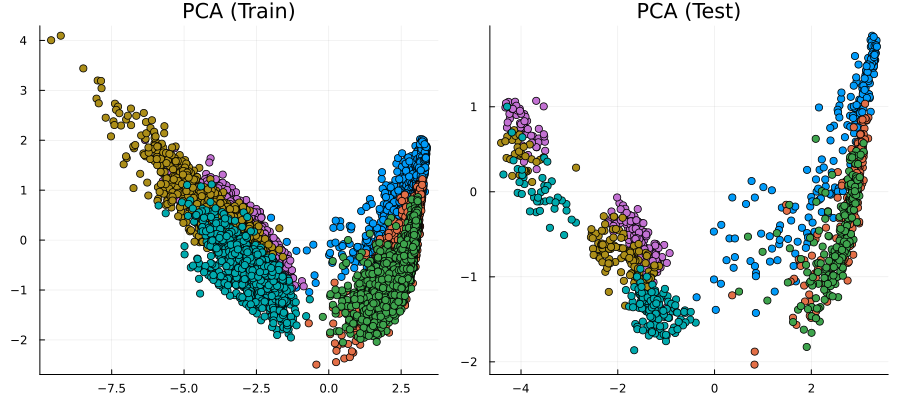

In [46]:
pca = MultivariateStats.fit(MultivariateStats.PCA, X_train'; maxoutdim=2)

Xtr_pca = MultivariateStats.transform(pca, X_train')'
Xte_pca = MultivariateStats.transform(pca, X_test')'

p_train = scatter(Xtr_pca[:,1], Xtr_pca[:,2],
        group=y_train, title="PCA (Train)", legend=false)

p_test = scatter(Xte_pca[:,1], Xte_pca[:,2],
        group=y_test, title="PCA (Test)", legend=false)
plot(p_train, p_test, layout=(1,2), size=(900,400))

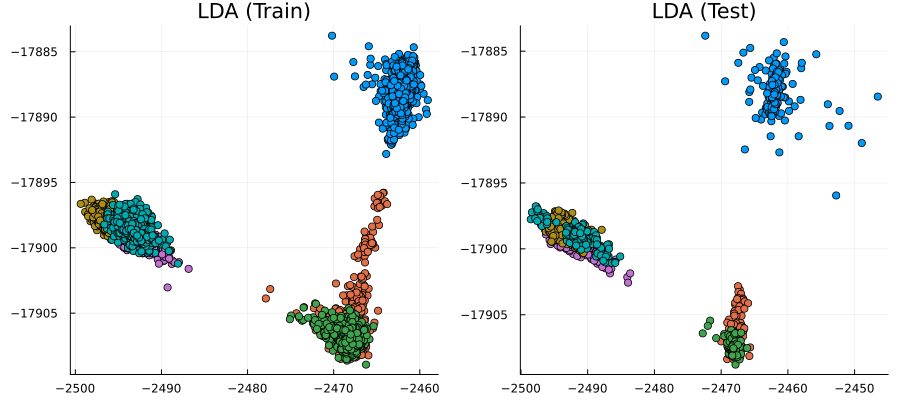

In [47]:
lda2 = CustomLDA(outdim=2)

fit_lda, _, _ = MMI.fit(lda2, 0, df_train)

Xtr_lda = MMI.transform(lda2, fit_lda, df_train)
Xte_lda = MMI.transform(lda2, fit_lda, df_test)

p_train = scatter(Xtr_lda[:,1], Xtr_lda[:,2],
        group=y_train, title="LDA (Train)", legend=false)

p_test = scatter(Xte_lda[:,1], Xte_lda[:,2],
        group=y_test, title="LDA (Test)", legend=false)

plot(p_train, p_test, layout=(1,2), size=(900,400))


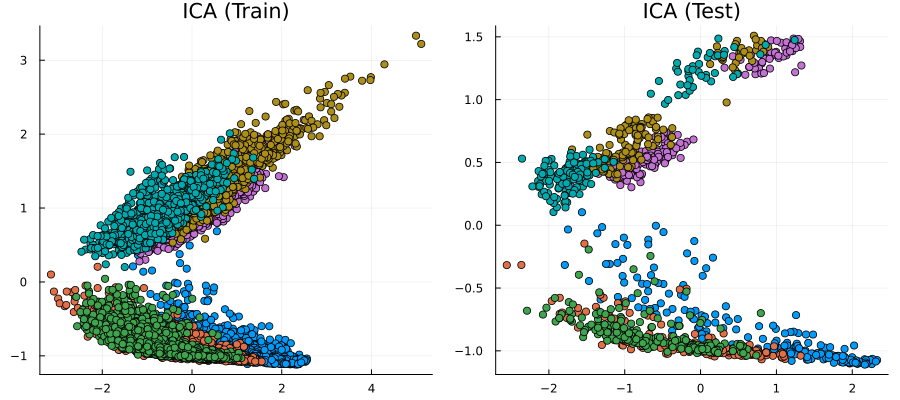

In [48]:
ica = MultivariateStats.fit(MultivariateStats.ICA, X_train', 2; maxiter=300, tol=1.0)

Xtr_ica = MultivariateStats.transform(ica, X_train')'
Xte_ica = MultivariateStats.transform(ica, X_test')'

p_train = scatter(Xtr_ica[:,1], Xtr_ica[:,2],
        group=y_train, title="ICA (Train)", legend=false)

p_test = scatter(Xte_ica[:,1], Xte_ica[:,2],
        group=y_test, title="ICA (Test)", legend=false)
plot(p_train, p_test, layout=(1,2), size=(900,400))

=== VISUALIZACIÓN t-SNE ===
[2025-12-18T20:04:43.431] Paso 1: Preparando datos de Test...
   -> Datos Test cargados: (1094, 561)
[2025-12-18T20:04:43.457] Paso 2: PCA sobre Test...
[2025-12-18T20:04:45.398] Paso 3: Calculando t-SNE...
 35.874328 seconds (15.68 M allocations: 1.004 GiB, 2.62% gc time, 20.50% compilation time)
[2025-12-18T20:05:21.392] Paso 4: Generando gráfico...


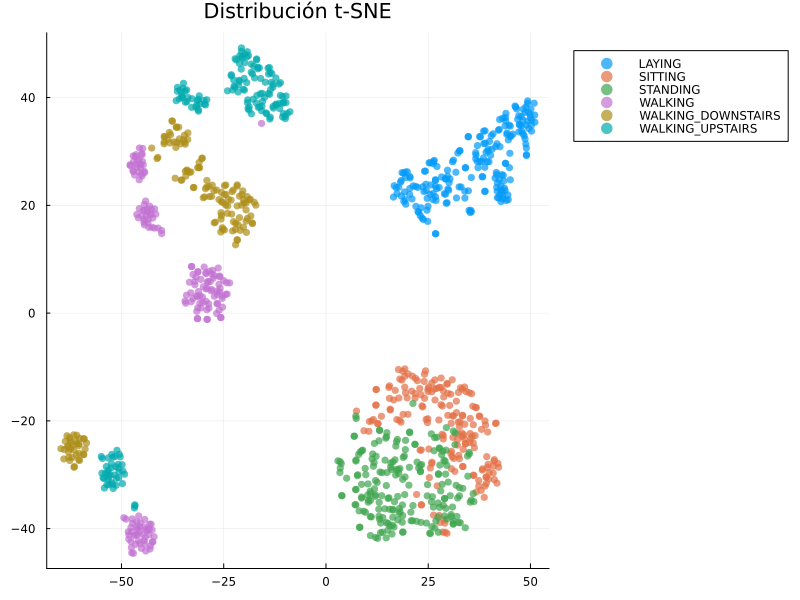

In [49]:
using ManifoldLearning
using Plots
using DataFrames
using MultivariateStats
using Dates

println("=== VISUALIZACIÓN t-SNE ===")
println("[$(now())] Paso 1: Preparando datos de Test...")

# =========================================================
# 1. PREPARACIÓN (Solo Test)
# =========================================================
try
    # Convertimos a matriz numérico (Float32 para velocidad)
    # Asumimos que X_test ya está cargado y limpio de columnas string
    global X_mat_test = Matrix{Float32}(Matrix(X_test))
    
    println("   -> Datos Test cargados: $(size(X_mat_test))")
catch e
    println("   ❌ Error: Asegúrate de tener 'X_test' cargado y sin columnas de texto.")
    rethrow(e)
end

# =========================================================
# 2. PCA (Reducción previa)
# =========================================================
println("[$(now())] Paso 2: PCA sobre Test...")

# Reducimos a 50 dimensiones
pca_model = MultivariateStats.fit(MultivariateStats.PCA, X_mat_test'; maxoutdim=50)
X_test_pca = MultivariateStats.transform(pca_model, X_mat_test')

# =========================================================
# 3. t-SNE
# =========================================================
println("[$(now())] Paso 3: Calculando t-SNE...")

@time tsne_model = ManifoldLearning.fit(
    ManifoldLearning.TSNE,
    X_test_pca;      
    maxoutdim = 2,   
    p = 30,          
    maxiter = 1000   # Al ser solo Test (menos datos), 1000 iteraciones irán rápido
)

# Obtenemos coordenadas
Y_test_final = ManifoldLearning.predict(tsne_model)' 

# =========================================================
# 4. VISUALIZAR
# =========================================================
println("[$(now())] Paso 4: Generando gráfico...")

p = scatter(
    Y_test_final[:,1], Y_test_final[:,2],
    group = y_test,          # Colores según la actividad real
    markershape = :circle,   # Círculos normales
    markersize = 4,
    alpha = 0.7,
    title = "Distribución t-SNE",
    legend = :outertopright,
    markerstrokewidth = 0,
    size = (800, 600)
)

display(p)


=== VISUALIZACIÓN ISOMAP ===
[2025-12-18T20:05:22.452] Paso 1: Calculando Isomap sobre X_test...
[2025-12-18T20:05:30.515] Paso 2: Generando gráfico...


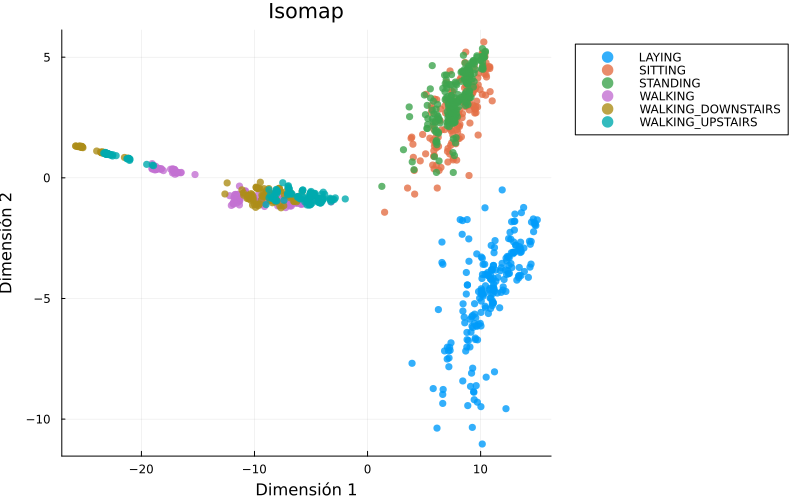

In [50]:
using ManifoldLearning
using Plots
using Dates

println("=== VISUALIZACIÓN ISOMAP ===")
println("[$(now())] Paso 1: Calculando Isomap sobre X_test...")

# 1. ENTRENAMIENTO (Directamente sobre Test)
# =========================================================
# Nota: ManifoldLearning espera (Features x Observaciones), por eso el ' al final de Matrix
isomap_model = ManifoldLearning.fit(
    ManifoldLearning.Isomap,
    Matrix(X_test)';     # <--- Transponer es vital aquí
    k = 12,              # Vecinos (puedes subir a 15-20 si sale muy disperso)
    maxoutdim = 2
)

# 2. TRANSFORMACIÓN
# =========================================================
# Obtenemos las coordenadas y transponemos de vuelta para el plot (N x 2)
Xte_iso = ManifoldLearning.predict(isomap_model)'

# 3. VISUALIZACIÓN
# =========================================================
println("[$(now())] Paso 2: Generando gráfico...")

p_test = scatter(
    Xte_iso[:,1], Xte_iso[:,2],
    group = y_test,
    title = "Isomap",
    xlabel = "Dimensión 1",
    ylabel = "Dimensión 2",
    markershape = :circle,
    markersize = 4,
    alpha = 0.8,
    markerstrokewidth = 0,
    legend = :outertopright,
    size = (800, 500)
)

display(p_test)


=== Visualización LLE (solo TEST) ===
   -> Datos Test: (561, 1094)
Calculando embedding LLE (k = 25)...


┌ Warning: Found 5 connected components. Largest component is selected.
└ @ ManifoldLearning C:\Users\selha\.julia\packages\ManifoldLearning\qUlAd\src\utils.jl:95


Generando gráfico LLE...


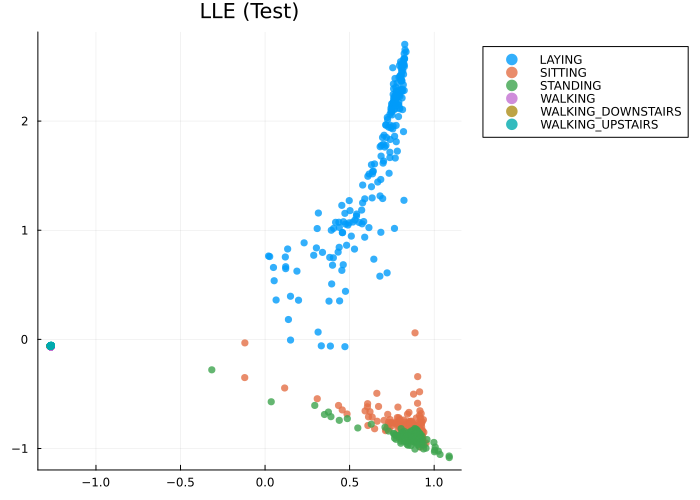

In [57]:
using ManifoldLearning
using Plots

println("=== Visualización LLE (solo TEST) ===")

# =========================================================
# 1. Preparación de datos (TEST)
# =========================================================
X_test_mat = Matrix(X_test)'   # (features × observaciones)
println("   -> Datos Test: ", size(X_test_mat))

# =========================================================
# 2. Ajuste LLE
# =========================================================
println("Calculando embedding LLE (k = 25)...")

lle_model = ManifoldLearning.fit(
    ManifoldLearning.LLE,
    X_test_mat;
    k = 25,
    maxoutdim = 2
)

# =========================================================
# 3. Obtener coordenadas y VÉRTICES VÁLIDOS
# =========================================================
Y_all = ManifoldLearning.transform(lle_model)'      # (N_valid × 2)
idx_valid = ManifoldLearning.vertices(lle_model)    # índices conservados

# Filtrar etiquetas SOLO a los puntos válidos
y_test_valid = y_test[idx_valid]

# =========================================================
# 4. Visualización
# =========================================================
println("Generando gráfico LLE...")

p = scatter(
    Y_all[:, 1], Y_all[:, 2],
    group = y_test_valid,
    markershape = :circle,
    markersize = 4,
    alpha = 0.8,
    title = "LLE (Test)",
    legend = :outertopright,
    markerstrokewidth = 0,
    size = (700, 500)
)

display(p)

In [58]:
# Comprobación de que hay clases solapadas
println("Clases originales en test:")
println(unique(y_test))

println("Clases tras LLE:")
println(unique(y_test_valid))

countmap(y_test_valid)

Clases originales en test:
String31["LAYING", "SITTING", "STANDING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "WALKING"]
Clases tras LLE:
String31["LAYING", "SITTING", "STANDING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "WALKING"]


Dict{CategoricalValue{String31, UInt32}, Int64} with 6 entries:
  String31("WALKING_DOWNSTAIRS") => 112
  String31("SITTING")            => 182
  String31("LAYING")             => 210
  String31("STANDING")           => 209
  String31("WALKING")            => 130
  String31("WALKING_UPSTAIRS")   => 123

# Análisis de Importancia de Variables: Random Forest vs. XGBoost

## 1. Configuración y Justificación Metodológica

Para realizar una comparativa justa y representativa de la importancia de características, hemos configurado los modelos respetando su naturaleza algorítmica y sus mecanismos de aprendizaje (Bagging vs. Boosting).

### A. Random Forest (Enfoque Bagging)
* *Configuración:* n_trees=100, *max_depth=15*.
* *Justificación:* Random Forest funciona mediante Bagging (Bootstrap Aggregating). Crea árboles independientes y paralelos que tienden a tener *alta varianza* (overfitting individual) pero bajo sesgo.
    * Al promediar muchos árboles inestables, la varianza se reduce.
    * Por ello, permitimos una *profundidad alta (15)*: necesitamos que cada árbol sea lo suficientemente complejo y "listo" para capturar interacciones profundas por sí mismo, ya que no aprenderá de los errores de sus compañeros.

### B. XGBoost (Enfoque Boosting)
* *Configuración:* n_rounds=100, *max_depth=6*.
* *Justificación:* XGBoost funciona mediante Boosting. Crea árboles secuenciales donde cada uno intenta corregir los errores residuales del anterior.
    * Es un reductor de *sesgo* (Bias).
    * Por ello, restringimos la *profundidad (6): necesitamos árboles "débiles" (*weak learners) o superficiales. Si permitiéramos árboles muy profundos en Boosting, el modelo memorizaría el ruido rápidamente (overfitting severo), perdiendo su capacidad de generalización.

---

## 2. Métricas de Importancia: ¿Qué estamos midiendo?

Es crucial entender que, aunque ambas gráficas muestran "importancia", matemáticamente están midiendo conceptos ligeramente diferentes debido a la implementación de las librerías:

1.  *Random Forest (Eje Y ~ 0.03): Ganancia de Información (Impureza Gini)*
    * Mide la *Calidad* del corte.
    * Representa cuánto reduce la impureza (entropía/Gini) una variable en promedio cada vez que se usa.
    * Favorece variables que discriminan muy bien clases grandes desde el principio.
    * Se reparte entre todas las variables de modo que la suma total de la ganancia con cada característica es 1.

2.  *XGBoost (Eje Y ~ 250): Frecuencia de Aparición o Weight*
    * Mide la *Cantidad* de uso.
    * Representa cuántas veces aparece una variable en los árboles del modelo para tomar una decisión.
    * Una variable puede tener una ganancia individual baja (cortes pequeños), pero ser fundamental porque se usa cientos de veces para "afinar" y corregir pequeñas decisiones en los bordes de decisión complejos.

---

## 3. Discusión de Resultados (Análisis de la Gráfica)

### A. Divergencia en el Tipo de Variables
Existe una *baja coincidencia* en el Top 10 de ambos modelos, lo cual tiene sentido ya que están resolviendo el problema mediante estrategias distintas:

* *Random Forest (Foco en Gravedad/Postura):*
    * Su variable reina es angle_X_gravityMean.
    * Domina las variables relacionadas con *Gravity* y *Angle*.
    * *Interpretación:* El RF está priorizando la *orientación del dispositivo*. Probablemente usa estas variables para distinguir rápidamente actividades estáticas (estar de pie, tumbado, sentado) basándose en la inclinación del móvil. Son cortes diferenciadores en el árbol.

* *XGBoost (Foco en Dinámica/Movimiento):*
    * Su variable reina es fBodyAccJerk_std_Y.
    * Domina las variables de *Body Acceleration* y *Jerk* (cambios bruscos de aceleración).
    * *Interpretación:* El XGBoost se está centrando en la *intensidad y brusquedad del movimiento. Al ser un modelo de refinamiento, usa estas variables frecuentemente para distinguir entre actividades dinámicas similares (ej. *Walking vs Walking Upstairs) donde la orientación es similar, pero la vibración (Jerk) es distinta.

### B. Conclusión 
El hecho de que los modelos no compartan las mismas variables principales no es un error, sino una *fortaleza*:

1.  *Complementariedad:* Confirma que Random Forest y XGBoost están extrayendo información diferente del dataset. El RF modela mejor la "postura global" (gravedad), mientras que XGBoost modela mejor los "matices del movimiento" (aceleración/jerk).
2.  *Justificación de Ensembles:* Esta divergencia es la razón teórica por la cual un *Ensemble* (o una votación entre ambos) funcionaría mejor que cualquiera de ellos por separado. Al combinarlos, obtendríamos un sistema que entiende tanto la orientación postural como la dinámica del movimiento.

--- Iniciando Análisis de Importancia de Variables ---


1. Entrenando Random Forest...
2. Entrenando XGBoost...


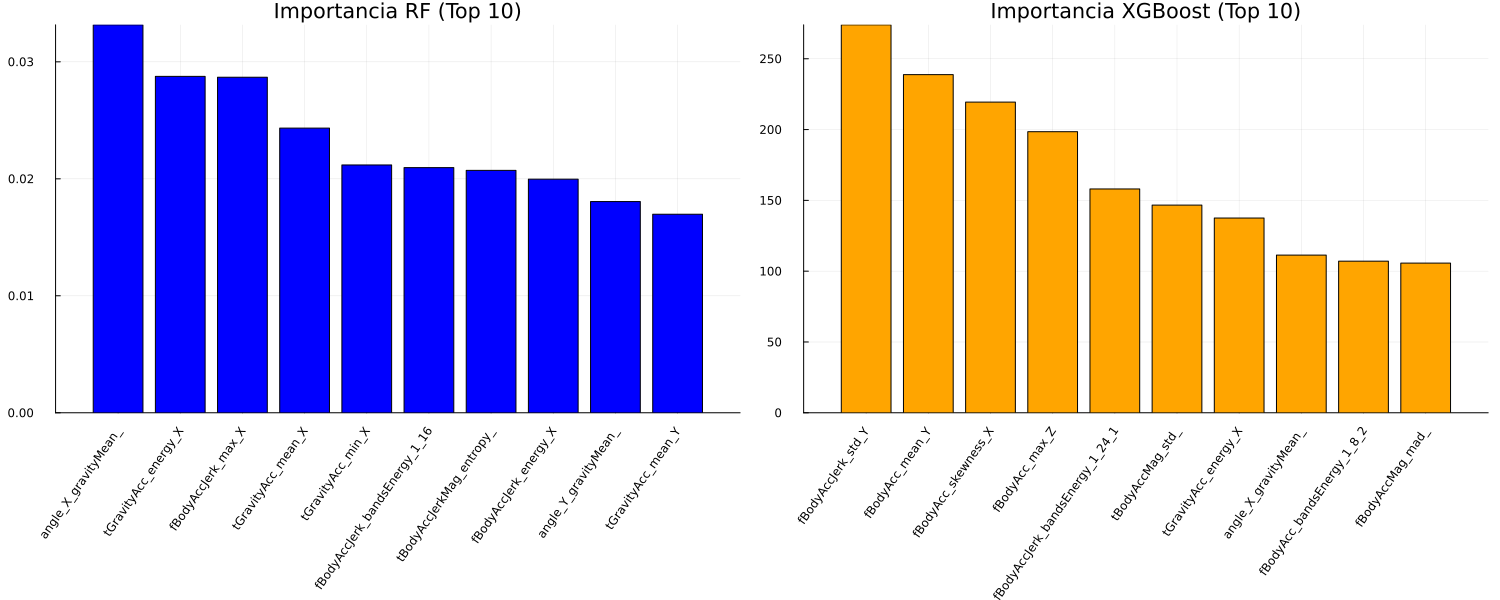

Gráficos generados y ordenados descendentemente.


In [ ]:
# =========================================================
# SIGNIFICACIÓN DE VARIABLES 
# =========================================================
using MLJDecisionTreeInterface
using MLJXGBoostInterface
using Plots
using DecisionTree
RFType = @load RandomForestClassifier pkg=DecisionTree verbosity=0
XGBType = @load XGBoostClassifier pkg=XGBoost verbosity=0

println("--- Iniciando Análisis de Importancia de Variables ---")

# Cargar datos completos (Train escalado)
df_tr_final = CSV.read("data_processed/dataset_train_scaled.csv", DataFrame)

# Preparar X e y
y_train_final = coerce(df_tr_final.Activity, Multiclass)
X_train_final = DataFrames.select(df_tr_final, Not([:subject, :Activity]))
X_train_final = coerce(X_train_final, Count => Continuous)



# ---------------------------------------------------------
# A. RANDOM FOREST
# ---------------------------------------------------------
println("1. Entrenando Random Forest...")

rf = RFType(n_trees=100, max_depth=10, rng=104)

# Entrenamiento del modelo
mach_rf = machine(rf, X_train_final, y_train_final)
MLJ.fit!(mach_rf, verbosity=0)

# Extraer y ordenar de mayor a menor (rev=true)
imps_rf = feature_importances(mach_rf)
top_rf = sort(imps_rf, by=x->x[2], rev=true)[1:10] # Cogemos el Top 30

# Preparar datos para plot
vars_rf = [String(x[1]) for x in top_rf]
vals_rf = [x[2] for x in top_rf]

p1 = bar(vars_rf, vals_rf, 
    title="Importancia RF (Top 10)", 
    xrotation=55, label=false, color=:blue, bottom_margin=25Plots.mm)

# ---------------------------------------------------------
# B. XGBOOST 
# ---------------------------------------------------------
println("2. Entrenando XGBoost...")

xgb = XGBType(num_round=100, max_depth=6, eta=0.1, objective="multi:softprob")

# Entrenamiento del modelo
mach_xgb = machine(xgb, X_train_final, y_train_final)
MLJ.fit!(mach_xgb, verbosity=0)

# Extraer y ordenar de mayor a menor (rev=true)
imps_xgb = feature_importances(mach_xgb)
top_xgb = sort(imps_xgb, by=x->x[2], rev=true)[1:10] # Cogemos el Top 30

# Preparar datos para plot
vars_xgb = [String(x[1]) for x in top_xgb]
vals_xgb = [x[2] for x in top_xgb]

p2 = bar(vars_xgb, vals_xgb, 
    title="Importancia XGBoost (Top 10)", 
    xrotation=55, label=false, color=:orange, bottom_margin=25Plots.mm)

# ---------------------------------------------------------
# C. VISUALIZACIÓN CONJUNTA
# ---------------------------------------------------------
final_plot = plot(p1, p2, layout=(1,2), size=(1500, 600))
display(final_plot)
println("Gráficos generados y ordenados descendentemente.")